# Analyse Exploratoire

### Import des modules

In [3988]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Analyse Exploratoire

In [3989]:
building_consumption = pd.read_csv("data/2016_Building_Energy_Benchmarking.csv")

In [3990]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [3991]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [3992]:
building_consumption.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'City', 'State', 'ZipCode',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus',
       'Outlier

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Qelques pistes d'analyse : 

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier 

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet. 

In [3993]:
# La colonne "BuildingType" semble contenir des informations sur le type de bâtiment.
# On regarde les différentes valeurs présentes dans cette colonne.
building_consumption['BuildingType'].value_counts()

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

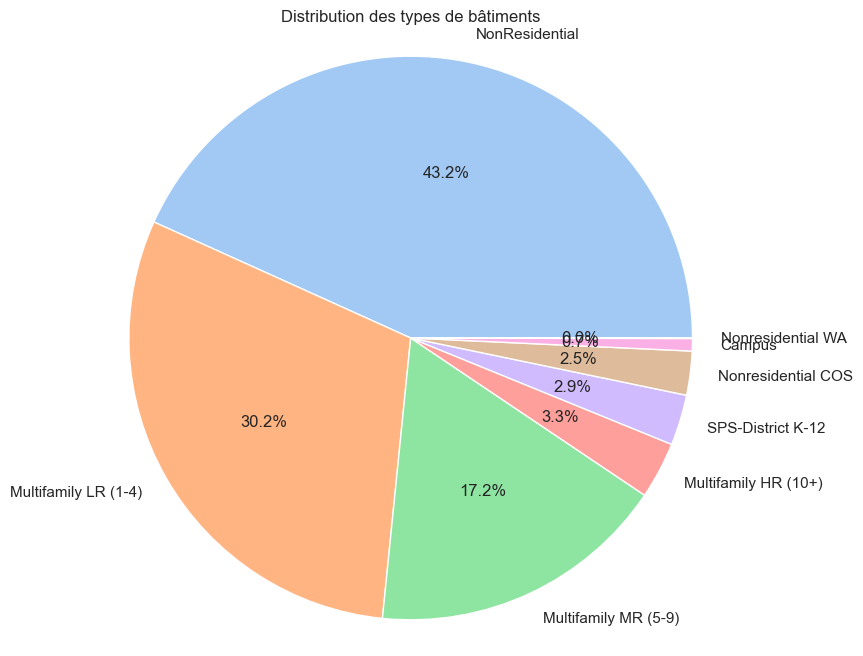

In [3994]:
# On affiche visuellement la composition des batiments BuildingType en utilisant seaborn pour une meilleure visualisation
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(8, 8))
building_consumption['BuildingType'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution des types de bâtiments')
plt.axis('equal')
plt.show()

In [3995]:
# Dans le cadre de cette analyse, on se concentre sur les bâtiments non résidentiels.
# On filtre les bâtiments résidentiels de notre jeu de données.
data = building_consumption.loc[~((building_consumption['BuildingType'] == 'Multifamily LR (1-4)') | (building_consumption['BuildingType'] == 'Multifamily MR (5-9)') | (building_consumption['BuildingType'] == 'Multifamily HR (10+)'))].copy()
# Save the filtered dataset to a new CSV file for future use
data.to_csv("data/filtered_non_residential_buildings.csv", index=False)

In [3996]:
# On regarde à nouveau les informations sur le jeu de données après avoir filtré les bâtiments résidentiels
data.info()

<class 'pandas.DataFrame'>
Index: 1668 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1668 non-null   int64  
 1   DataYear                         1668 non-null   int64  
 2   BuildingType                     1668 non-null   str    
 3   PrimaryPropertyType              1668 non-null   str    
 4   PropertyName                     1668 non-null   str    
 5   Address                          1668 non-null   str    
 6   City                             1668 non-null   str    
 7   State                            1668 non-null   str    
 8   ZipCode                          1652 non-null   float64
 9   TaxParcelIdentificationNumber    1668 non-null   str    
 10  CouncilDistrictCode              1668 non-null   int64  
 11  Neighborhood                     1668 non-null   str    
 12  Latitude                         166

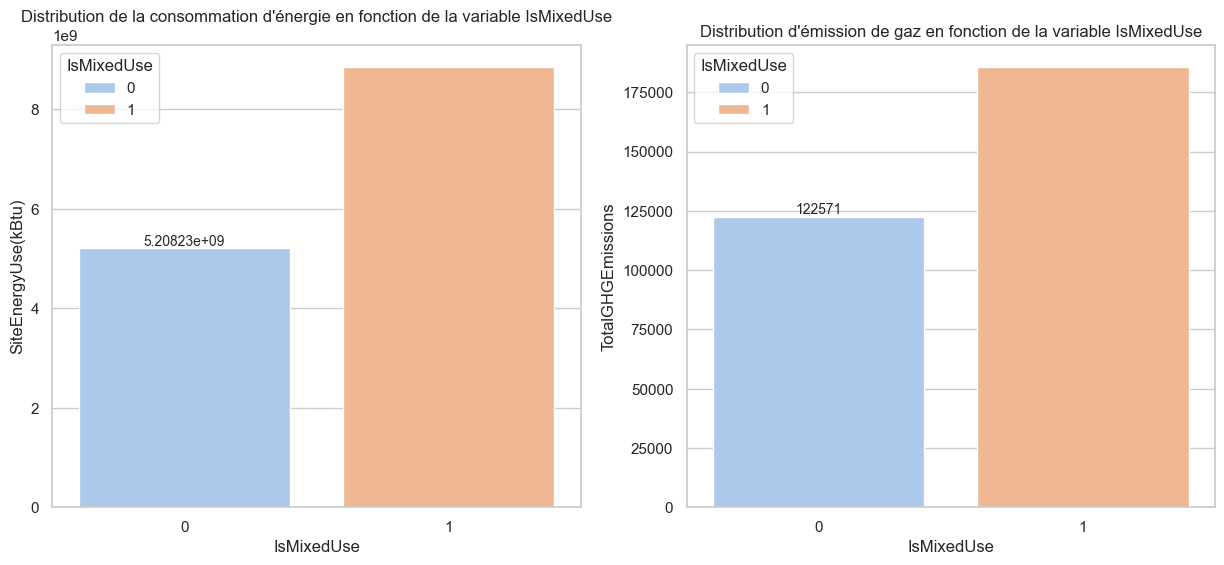

In [3997]:
# On veut mettre en évidence les différences entre les bâtiments à usage multiple.
# On ajoute la colonne IsMixedUse, sa valeur est 1 si la colonne "SecondLargestPropertyUseType" est non nulle
data['IsMixedUse'] = data['SecondLargestPropertyUseType'].notnull().astype(int)

# On affiche un graphique bar de la distribution de la consommation d'énergie (SiteEnergyUse(kBtu)) en fonction de la variable IsMixedUse
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
ax = sns.barplot(x='IsMixedUse', y='SiteEnergyUse(kBtu)', data=data, hue='IsMixedUse', estimator='sum', errorbar=None)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Distribution de la consommation d\'énergie en fonction de la variable IsMixedUse')
# plt.show()

# On affiche un graphique bar de la distribution d'émission de gaz (TotalGHGEmissions) en fonction de la variable IsMixedUse
# plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 2)
ax = sns.barplot(x='IsMixedUse', y='TotalGHGEmissions', data=data, hue='IsMixedUse', estimator='sum', errorbar=None)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Distribution d\'émission de gaz en fonction de la variable IsMixedUse')
plt.show()

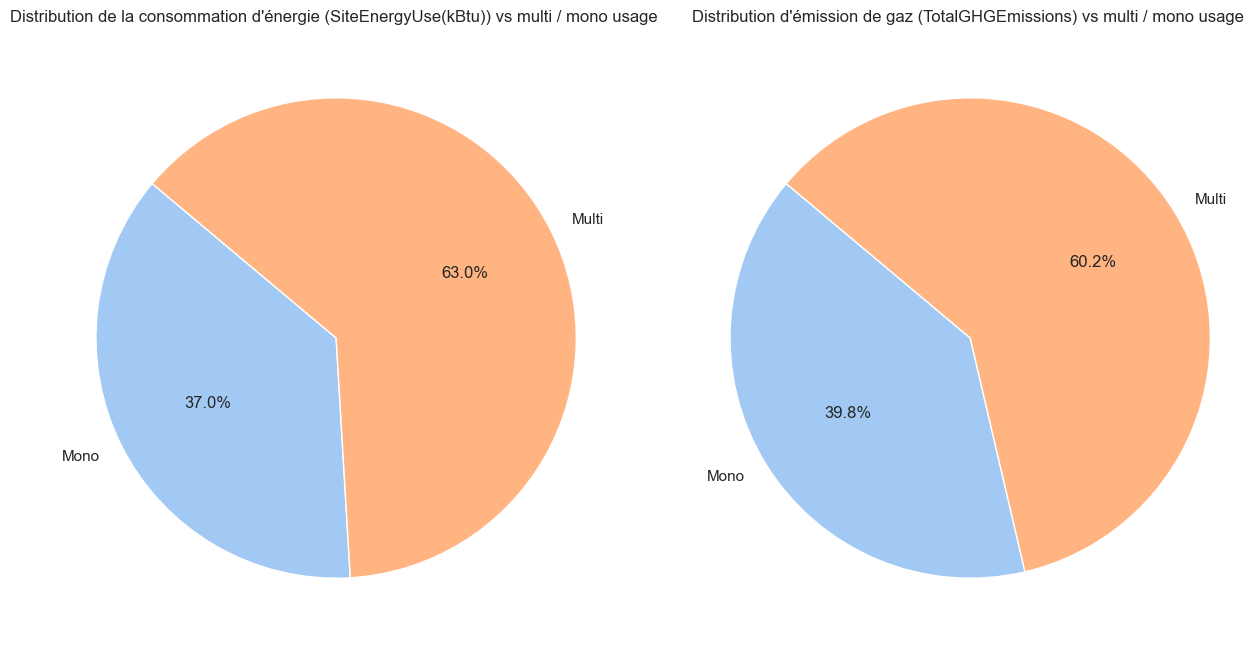

In [3998]:
# On affiche un graphique camembert de la distribution de la consommation d'énergie (SiteEnergyUse(kBtu)) en fonction de la variable IsMixedUse. On utilisera les labels "Multi" et "Mono" pour différencier les deux catégories.
labels = ['Mono', 'Multi']
sizes = data.groupby('IsMixedUse')['SiteEnergyUse(kBtu)'].sum()
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Distribution de la consommation d\'énergie (SiteEnergyUse(kBtu)) vs multi / mono usage ')
plt.axis('equal')
# plt.show()

# On affiche un graphique camembert de la distribution d'émission de gaz (TotalGHGEmissions) en fonction de la variable IsMixedUse. On utilisera les labels "Multi" et "Mono" pour différencier les deux catégories.
sizes = data.groupby('IsMixedUse')['TotalGHGEmissions'].sum()
plt.subplot(1, 2, 2)
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Distribution d\'émission de gaz (TotalGHGEmissions) vs multi / mono usage ')
plt.axis('equal')
plt.show()

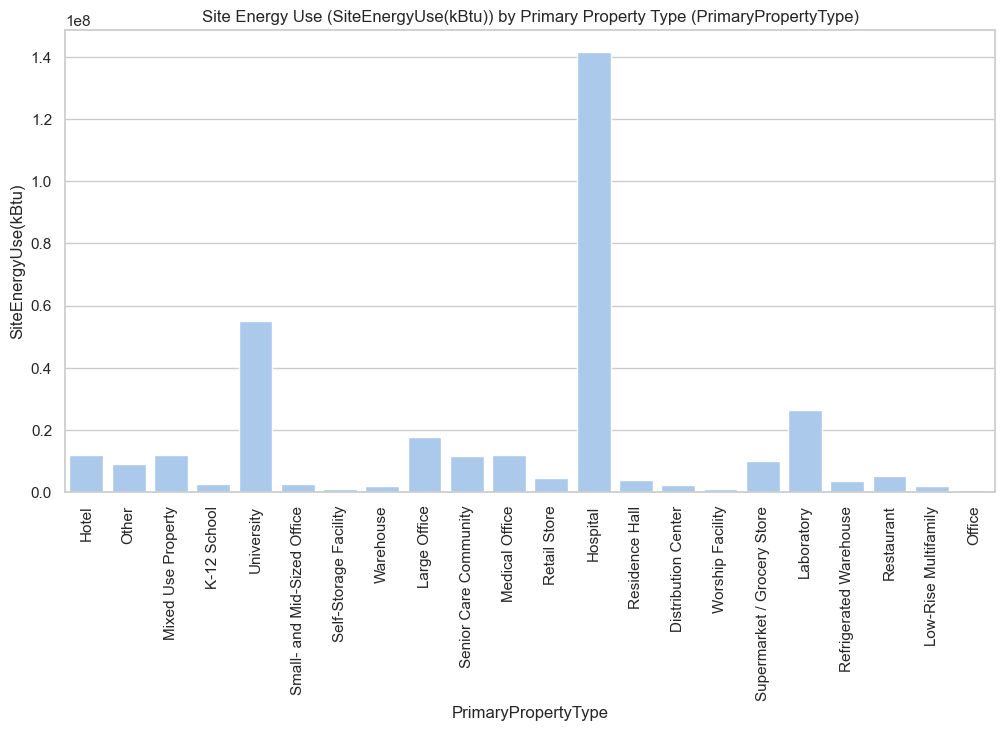

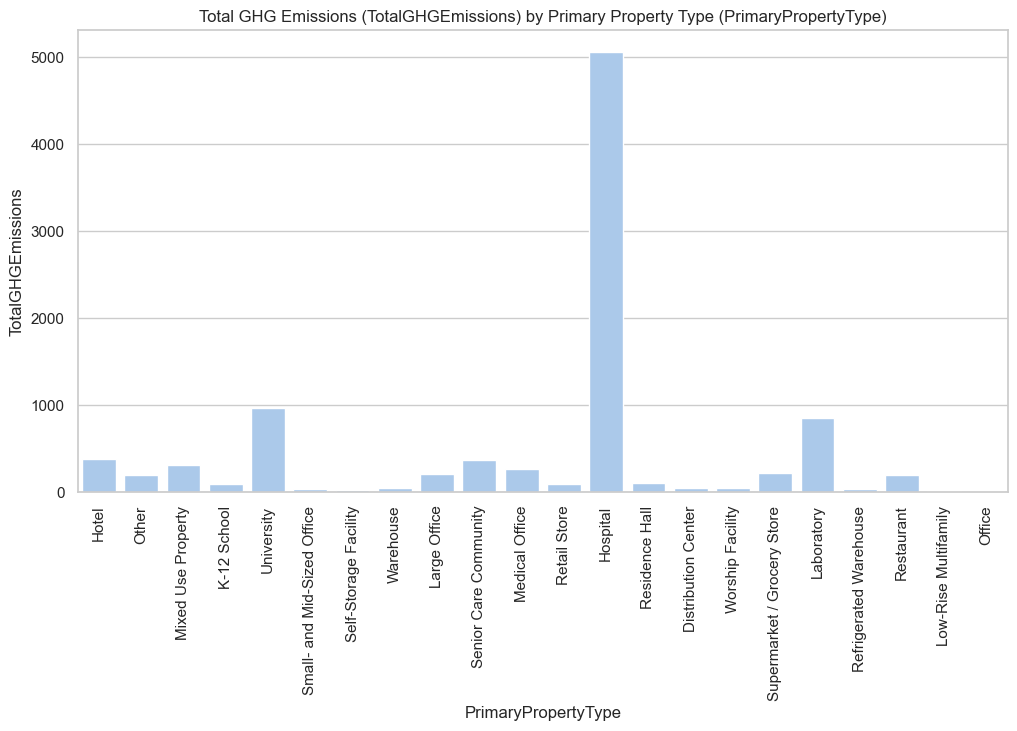

In [3999]:
# On affiche "SiteEnergyUse(kBtu)" vs PrimaryPropertyType sur un bar
plt.figure(figsize=(12, 6))
sns.barplot(x='PrimaryPropertyType', y='SiteEnergyUse(kBtu)', data=data, estimator='mean', errorbar=None)
plt.xticks(rotation=90)
plt.title('Site Energy Use (SiteEnergyUse(kBtu)) by Primary Property Type (PrimaryPropertyType)')
plt.show()

# On affiche "TotalGHGEmissions" vs PrimaryPropertyType sur un bar
plt.figure(figsize=(12, 6))
sns.barplot(x='PrimaryPropertyType', y='TotalGHGEmissions', data=data, estimator='mean', errorbar=None)
plt.xticks(rotation=90)
plt.title('Total GHG Emissions (TotalGHGEmissions) by Primary Property Type (PrimaryPropertyType)')
plt.show()

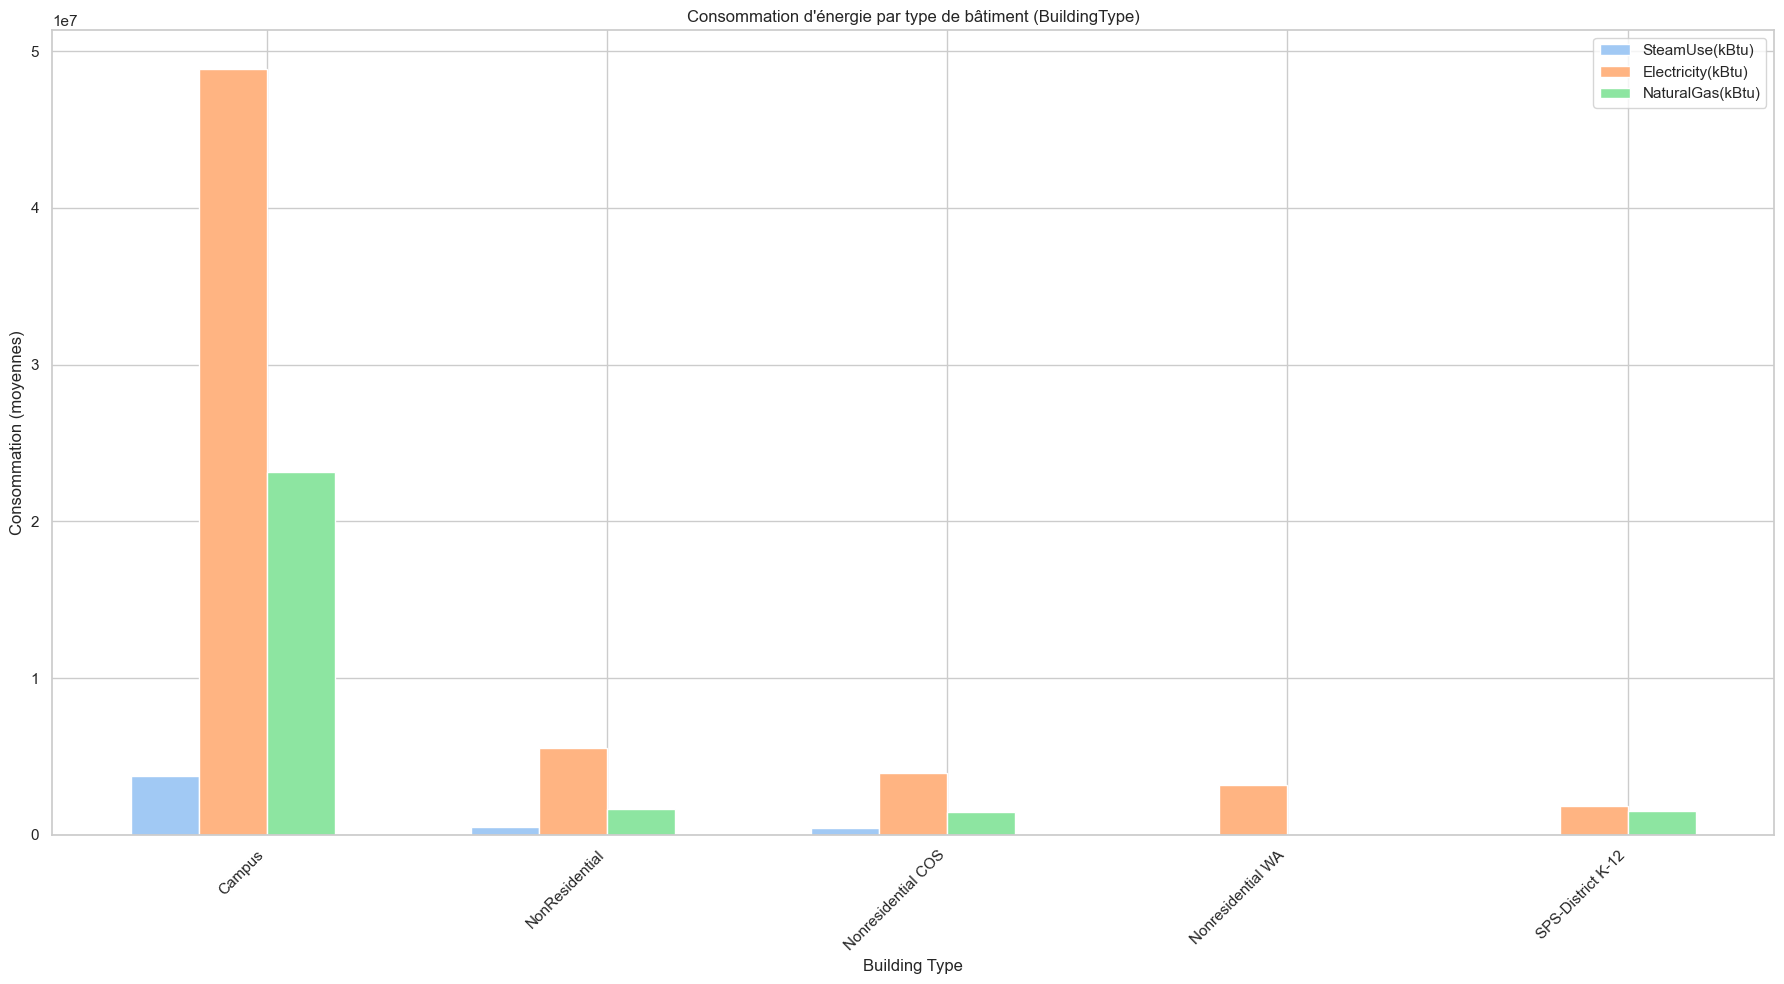

In [4000]:
# Consommation d'énergie par BuildingType
# Sélectionner les colonnes d'intérêt et grouper par BuildingType
energy_columns = ['SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)']
energy_by_building = data[['BuildingType'] + energy_columns].groupby('BuildingType').mean()

# Créer le graphique en bar groupées
fig, ax = plt.subplots(figsize=(18, 10))
x = range(len(energy_by_building.index))
width = 0.2

for i, col in enumerate(energy_columns):
    ax.bar([p + width * i for p in x], energy_by_building[col], width, label=col)

ax.set_xlabel('Building Type')
ax.set_ylabel('Consommation (moyennes)')
ax.set_title('Consommation d\'énergie par type de bâtiment (BuildingType)')
ax.set_xticks([p + width * 1.5 for p in x])
ax.set_xticklabels(energy_by_building.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

Distribution de LargestPropertyUseType :


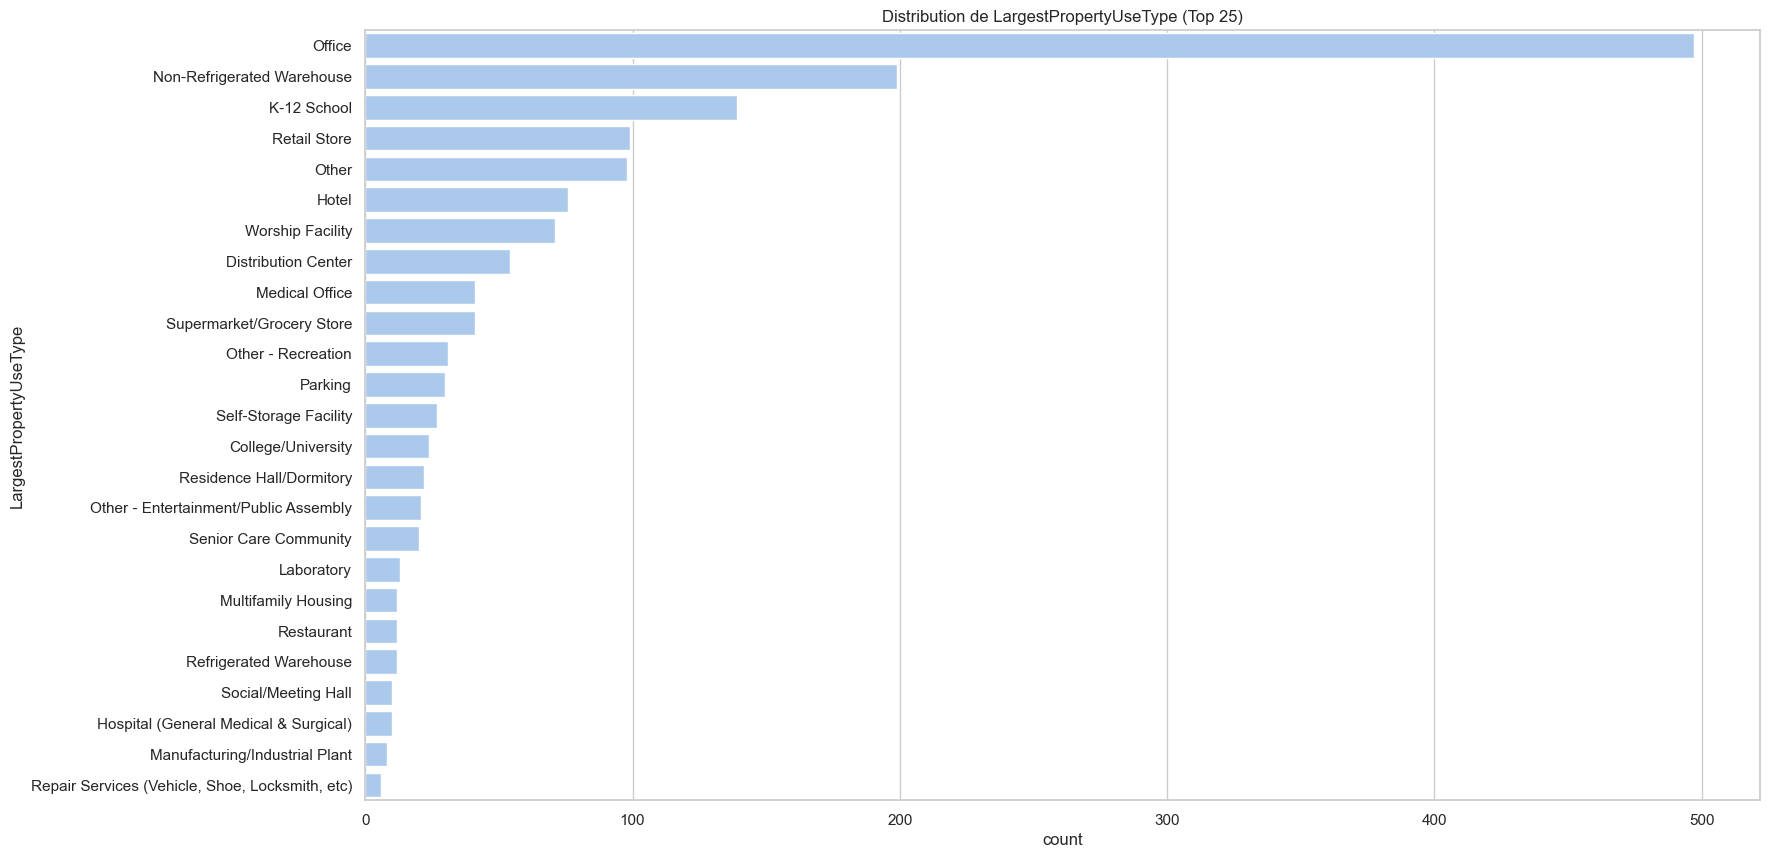

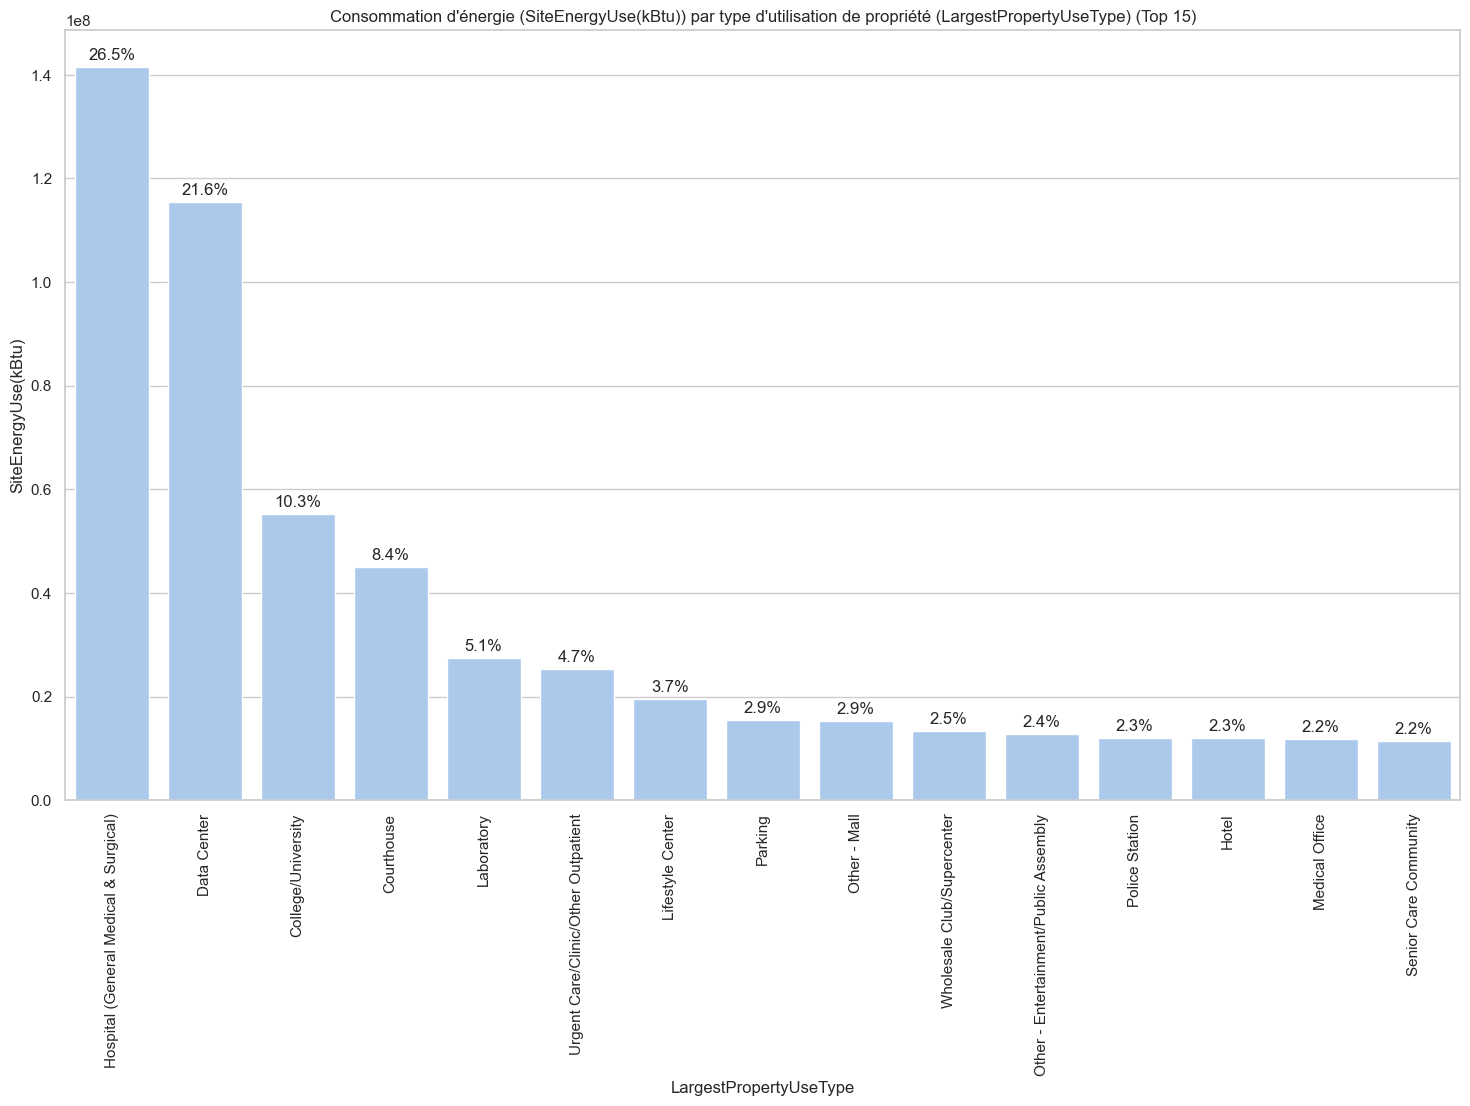

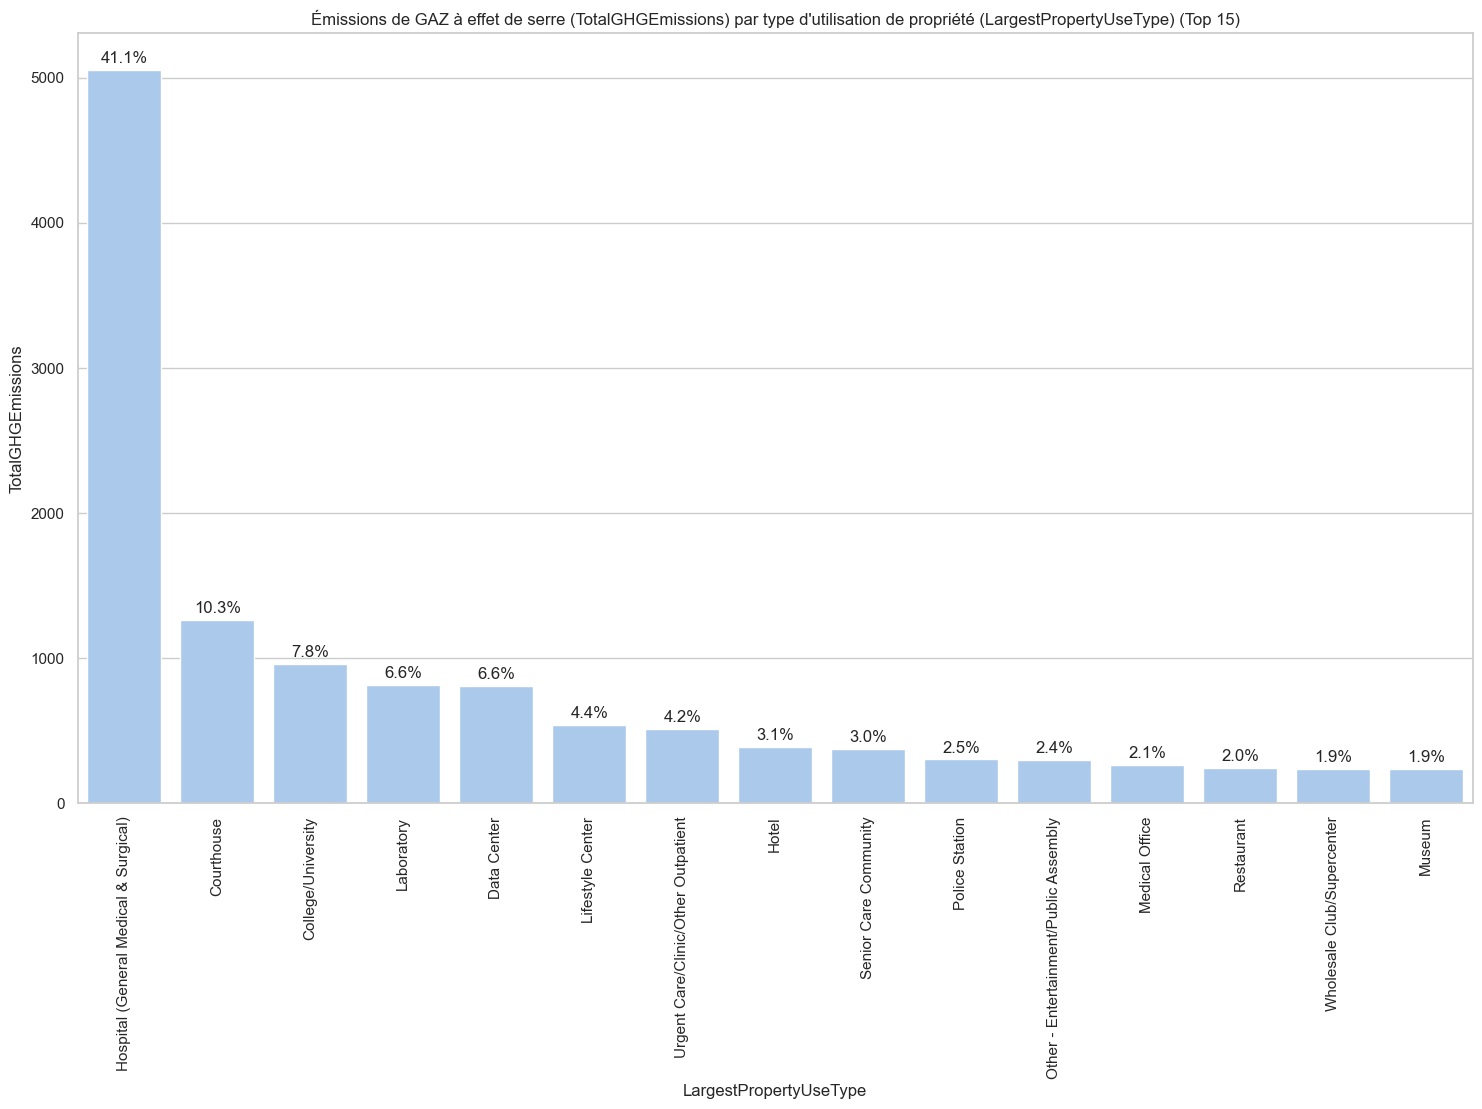

In [4001]:
# On examine "LargestPropertyUseType"
print("Distribution de LargestPropertyUseType :")
# print(data['LargestPropertyUseType'].value_counts())
# On affiche la distribution de "LargestPropertyUseType", des 25 catégories les plus fréquentes en utilisant un graphique à barres
plt.figure(figsize=(18, 10))
sns.countplot(y='LargestPropertyUseType', data=data, order=data['LargestPropertyUseType'].value_counts().nlargest(25).index)
plt.title('Distribution de LargestPropertyUseType (Top 25)')
plt.show()

# On affiche "SiteEnergyUse(kBtu)" vs LargestPropertyUseType sur un bar pour les 15 catégories les plus fréquentes par ordre décroissant de consommation d'énergie moyenne
plt.figure(figsize=(18, 10))
top_15_use = data.groupby('LargestPropertyUseType')['SiteEnergyUse(kBtu)'].mean().nlargest(15)
top_15_use_percent = (top_15_use / top_15_use.sum()) * 100
top_15_use_types = top_15_use.index
ax = sns.barplot(x='LargestPropertyUseType', y='SiteEnergyUse(kBtu)', data=data[data['LargestPropertyUseType'].isin(top_15_use_types)], order=top_15_use_types, errorbar=None)
# Ajouter les étiquettes de valeur en pourcentage au-dessus de chaque barre
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in top_15_use_percent], padding=3)
plt.xticks(rotation=90)
plt.title('Consommation d\'énergie (SiteEnergyUse(kBtu)) par type d\'utilisation de propriété (LargestPropertyUseType) (Top 15)')
plt.show()

# On affiche "TotalGHGEmissions" vs LargestPropertyUseType sur un bar pour les 15 catégories les plus fréquentes par ordre décroissant d'émissions de GAZ à effet de serre moyenne
plt.figure(figsize=(18, 10))
top_15_use = data.groupby('LargestPropertyUseType')['TotalGHGEmissions'].mean().nlargest(15)
top_15_use_percent = (top_15_use / top_15_use.sum()) * 100
top_15_use_types = top_15_use.index
ax = sns.barplot(x='LargestPropertyUseType', y='TotalGHGEmissions', data=data[data['LargestPropertyUseType'].isin(top_15_use_types)], order=top_15_use_types, errorbar=None)
# Ajouter les étiquettes de valeur en pourcentage au-dessus de chaque barre
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in top_15_use_percent], padding=3)
plt.xticks(rotation=90)
plt.title('Émissions de GAZ à effet de serre (TotalGHGEmissions) par type d\'utilisation de propriété (LargestPropertyUseType) (Top 15)')
plt.show()


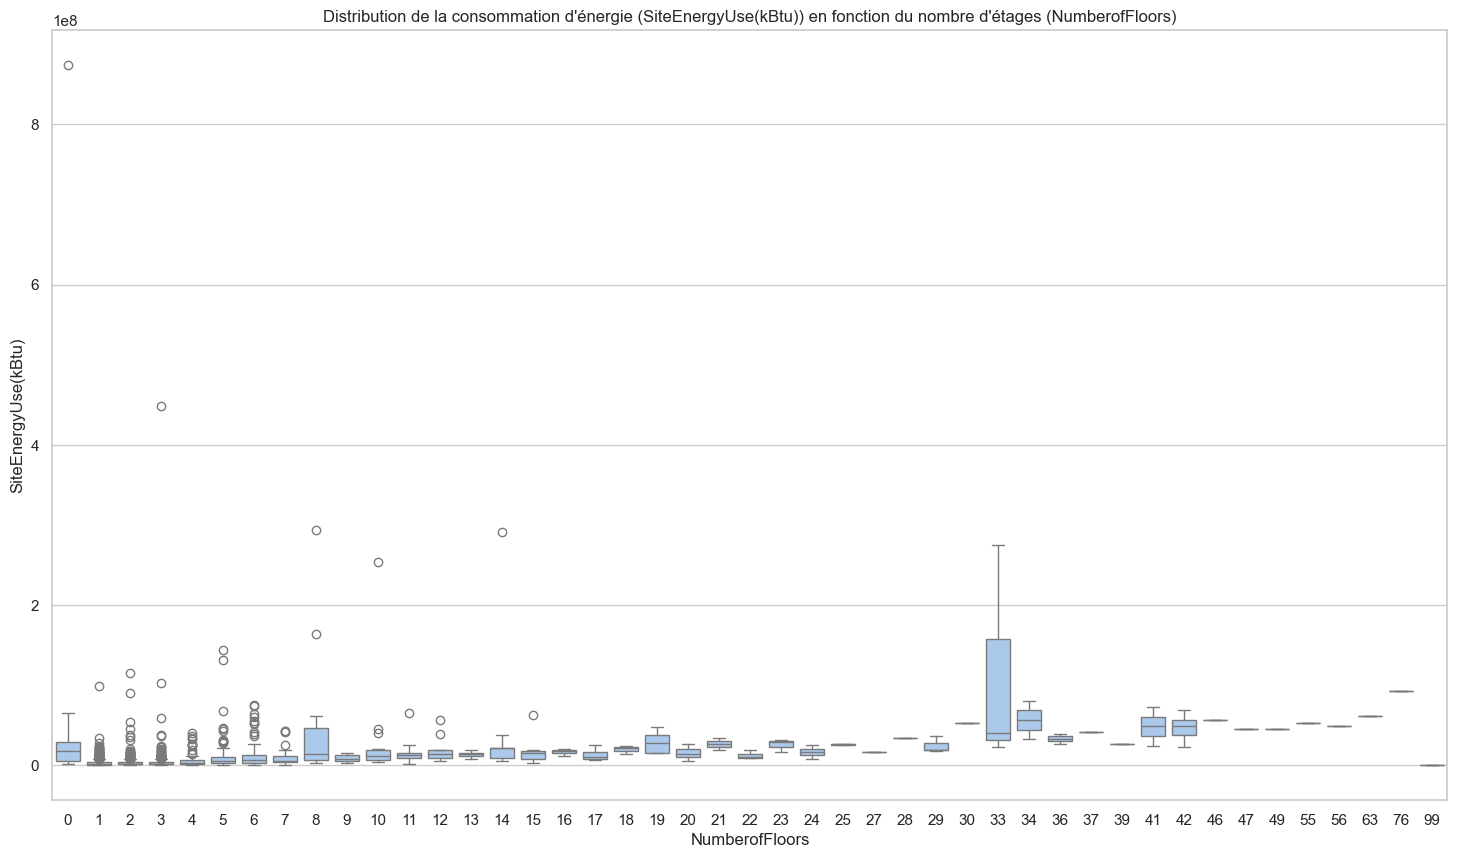

In [4002]:
# On affiche la distribution de la consommation d'énergie (SiteEnergyUse(kBtu)) en fonction de nombre d'étages (NumberofFloors)
plt.figure(figsize=(18, 10))
sns.boxplot(x='NumberofFloors', y='SiteEnergyUse(kBtu)', data=data)
plt.title('Distribution de la consommation d\'énergie (SiteEnergyUse(kBtu)) en fonction du nombre d\'étages (NumberofFloors)')
plt.xlabel('NumberofFloors')
plt.ylabel('SiteEnergyUse(kBtu)')
plt.show()

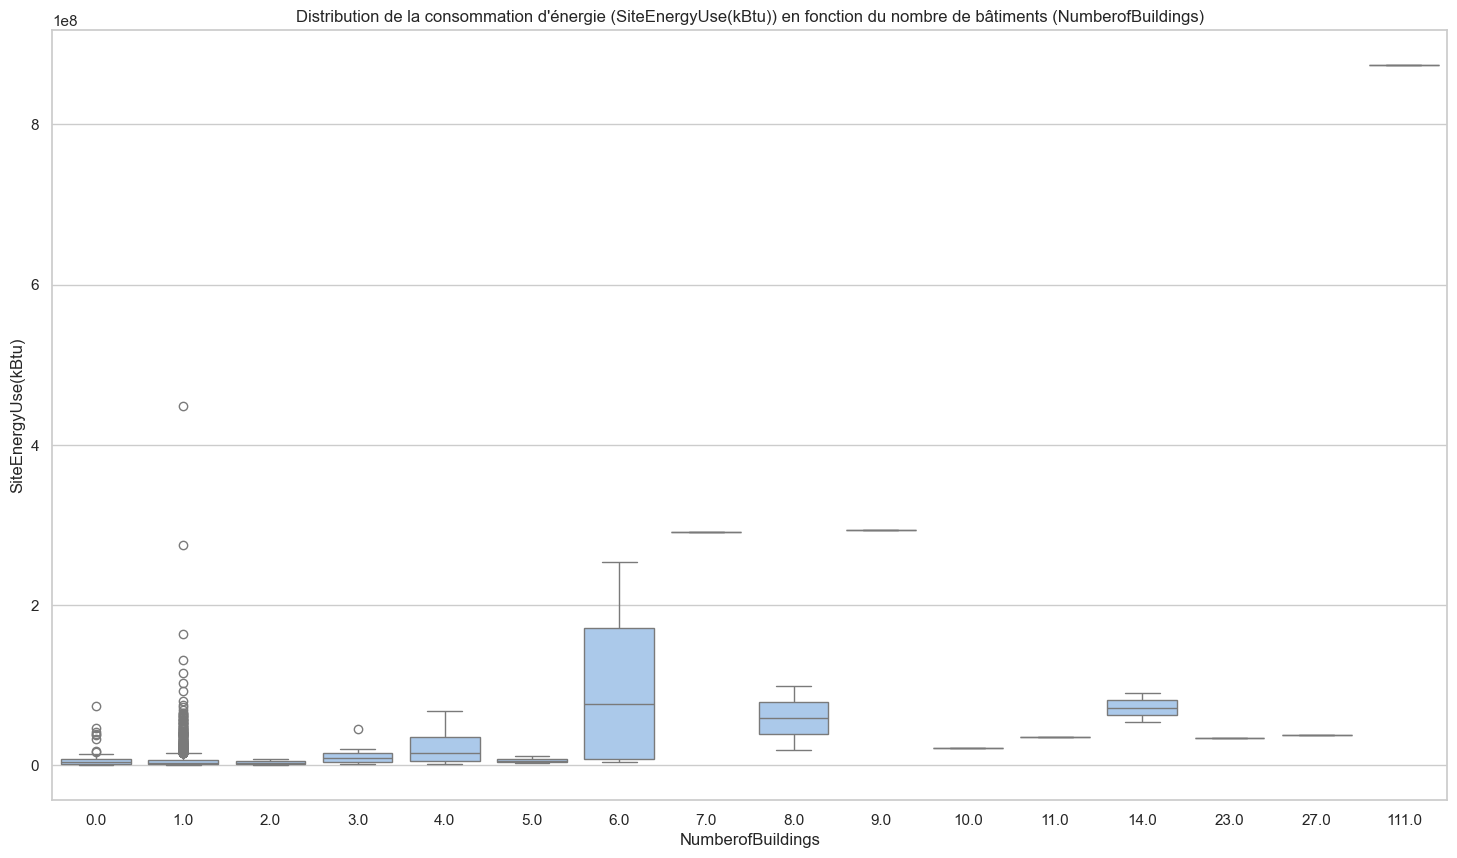

In [4003]:
# On affiche la distribution de la consommation d'énergie (SiteEnergyUse(kBtu)) en fonction de nombre de bâtiments (NumberofBuildings)
plt.figure(figsize=(18, 10))
sns.boxplot(x='NumberofBuildings', y='SiteEnergyUse(kBtu)', data=data)
plt.title('Distribution de la consommation d\'énergie (SiteEnergyUse(kBtu)) en fonction du nombre de bâtiments (NumberofBuildings)')
plt.xlabel('NumberofBuildings')
plt.ylabel('SiteEnergyUse(kBtu)')
plt.show()

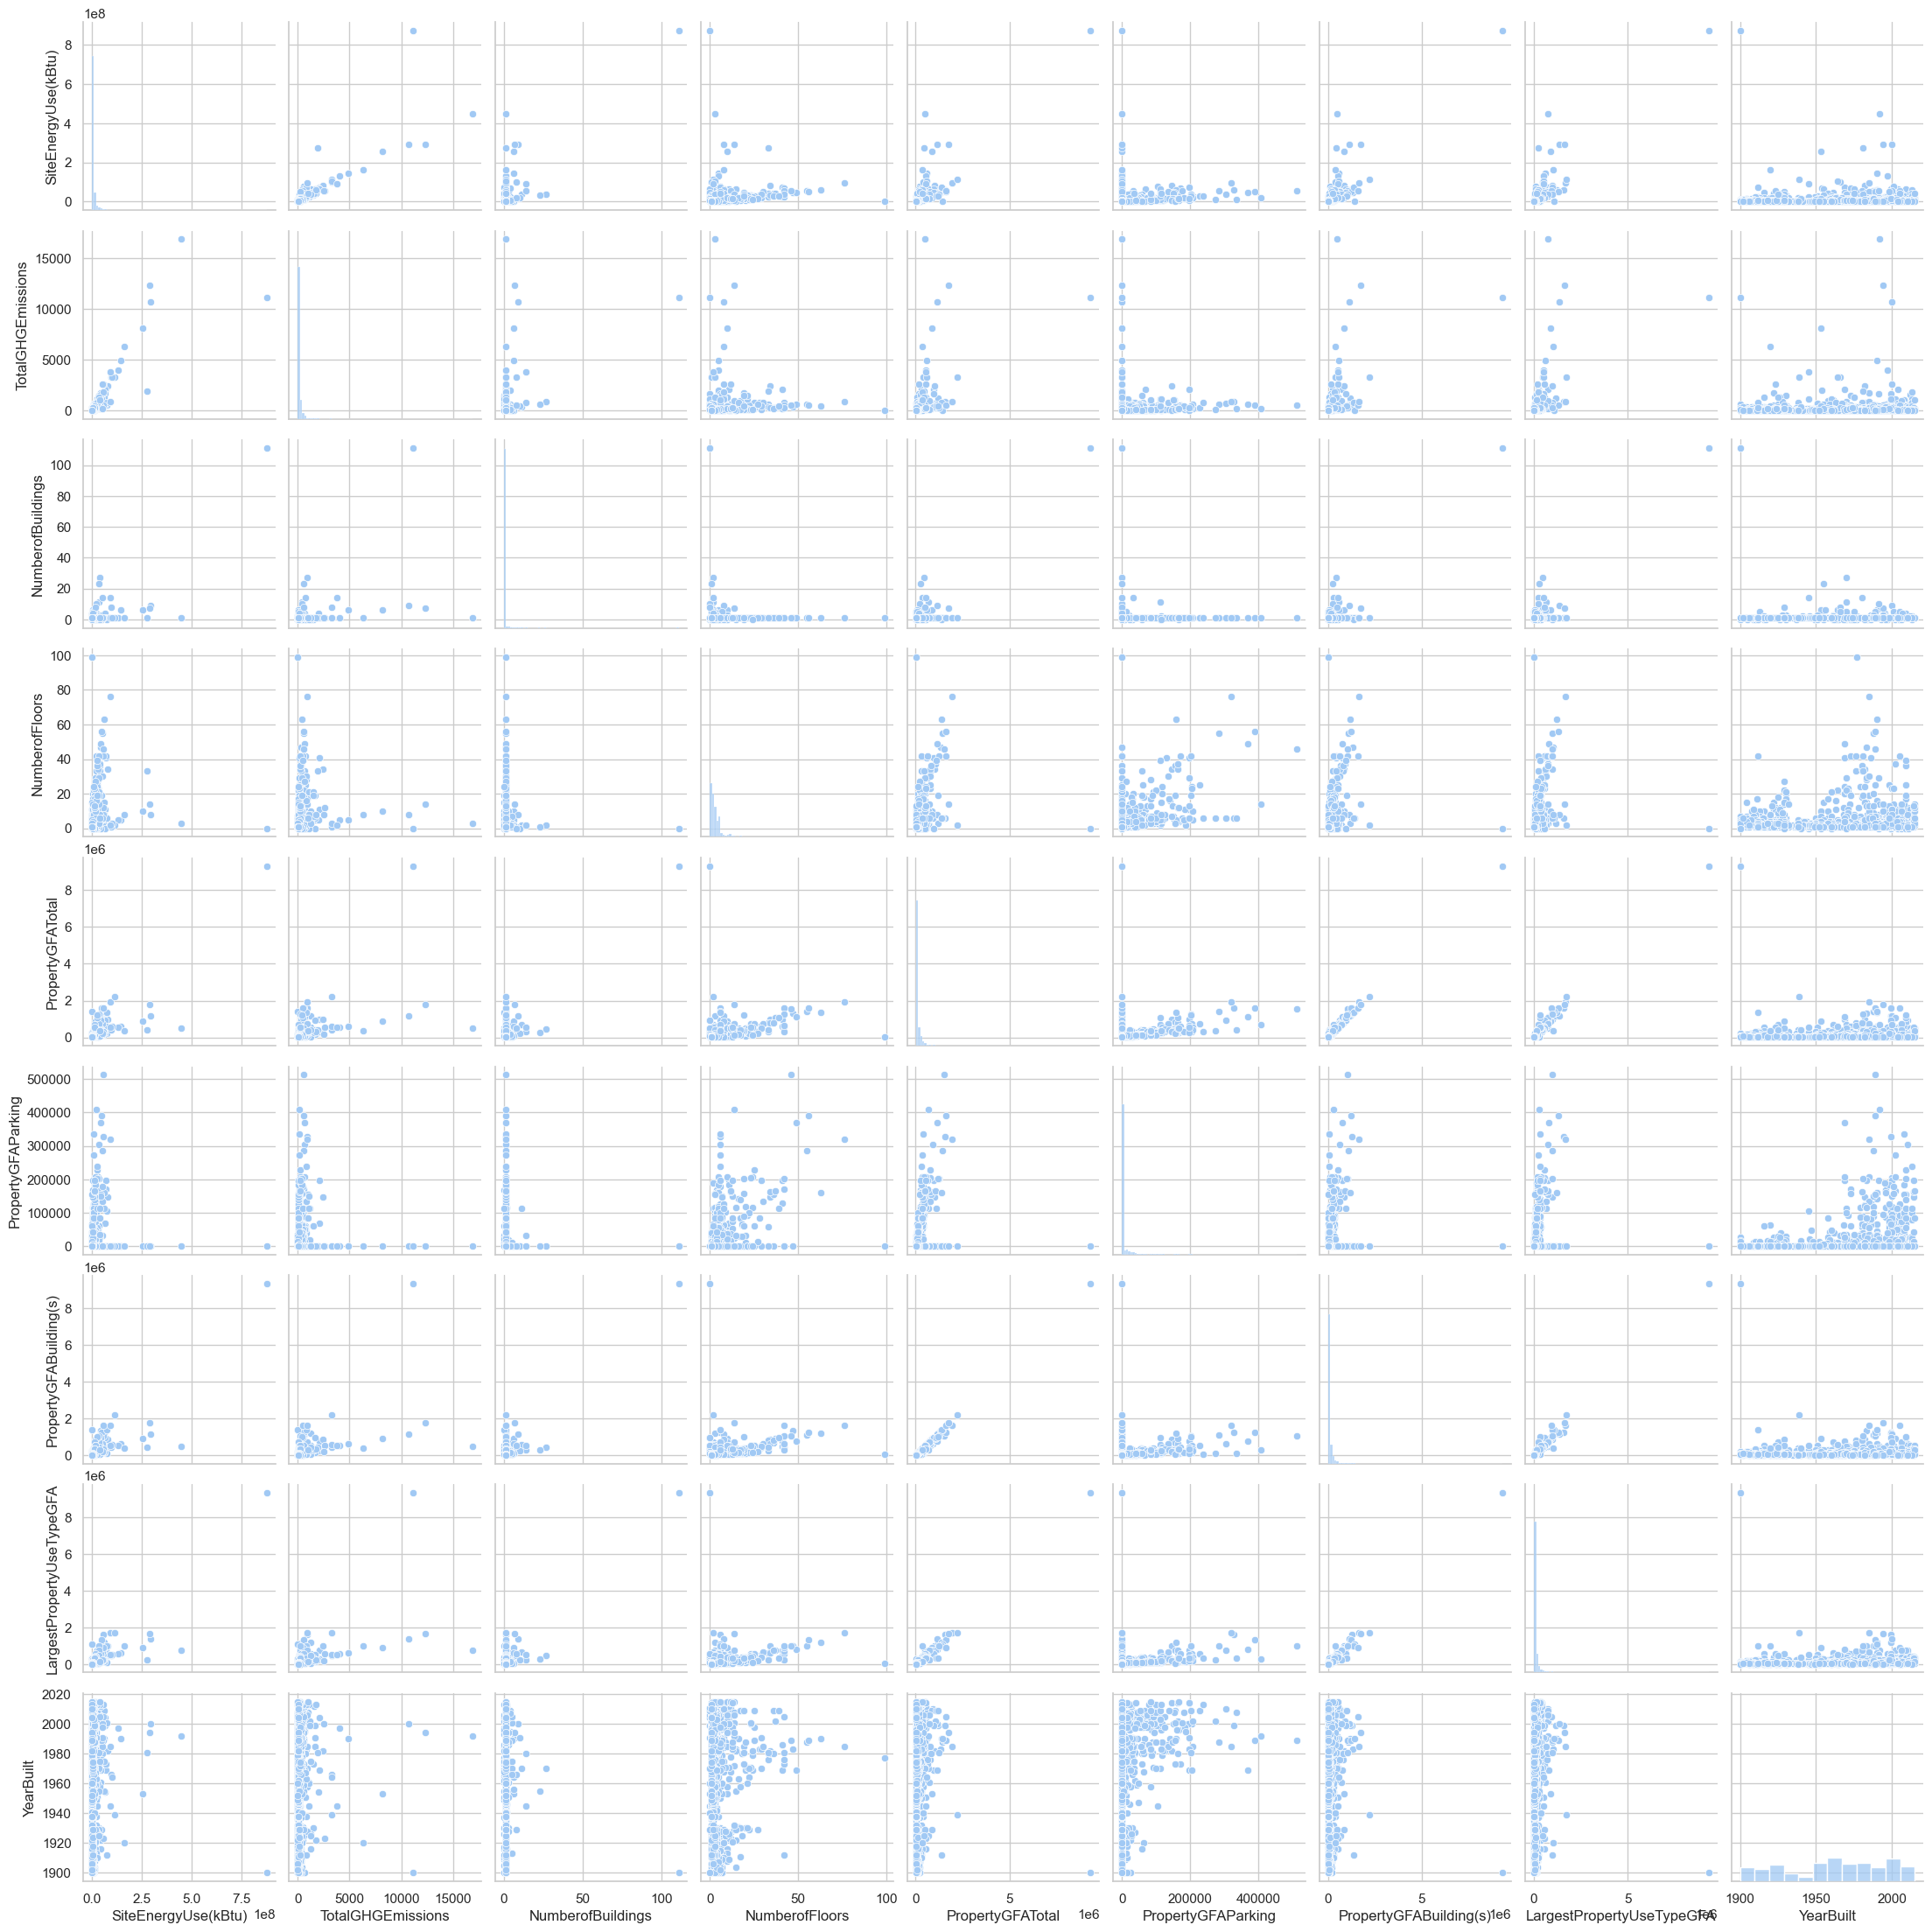

In [4004]:
columns_to_analyze = [
    'SiteEnergyUse(kBtu)',
    'TotalGHGEmissions',
    'NumberofBuildings',
    'NumberofFloors',
    'PropertyGFATotal',
    'PropertyGFAParking',
    'PropertyGFABuilding(s)',
    'LargestPropertyUseTypeGFA',
    'YearBuilt'
]

# Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier
sns.pairplot(data[columns_to_analyze])
plt.show()


In [4005]:
# On affiche les données avec TotalGHGEmissions <= 0 ou SiteEnergyUse(kBtu) <= 0
print(data.loc[(data['TotalGHGEmissions'] <= 0) | (data['SiteEnergyUse(kBtu)'] <= 0), ['TotalGHGEmissions', 'SiteEnergyUse(kBtu)', 'LargestPropertyUseType']])

# On supprime les lignes avec SiteEnergyUse(kBtu) <= 0 ou TotalGHGEmissions <= 0
print("Nombre de lignes avant suppression des valeurs <= 0 : ", data.shape[0])
data = data.loc[(data['SiteEnergyUse(kBtu)'] > 0) & (data['TotalGHGEmissions'] > 0)]
print("Nombre de lignes après suppression des valeurs <= 0 : ", data.shape[0])

      TotalGHGEmissions  SiteEnergyUse(kBtu)     LargestPropertyUseType
28                 0.00         0.000000e+00                K-12 School
31                10.43         0.000000e+00                K-12 School
62                 4.19         0.000000e+00                K-12 School
81                11.84         0.000000e+00                K-12 School
85                16.36         0.000000e+00                K-12 School
95                14.67         0.000000e+00                K-12 School
133              229.38         0.000000e+00                K-12 School
139              170.90         0.000000e+00                K-12 School
152                0.00         0.000000e+00                K-12 School
304                0.00         0.000000e+00          Convention Center
513                0.00         1.252517e+07  Supermarket/Grocery Store
614               13.64         0.000000e+00                K-12 School
630                9.99         0.000000e+00                K-12

SiteEnergyUse(kBtu) descriptive statistics summary :
count    1.648000e+03
mean     8.522287e+06
std      3.039631e+07
min      1.680890e+04
25%      1.257589e+06
50%      2.593203e+06
75%      6.962459e+06
max      8.739237e+08
Name: SiteEnergyUse(kBtu), dtype: float64

TotalGHGEmissions descriptive statistics summary :
count     1648.000000
mean       186.510613
std        755.880837
min          0.120000
25%         20.475000
50%         49.845000
75%        143.607500
max      16870.980000
Name: TotalGHGEmissions, dtype: float64


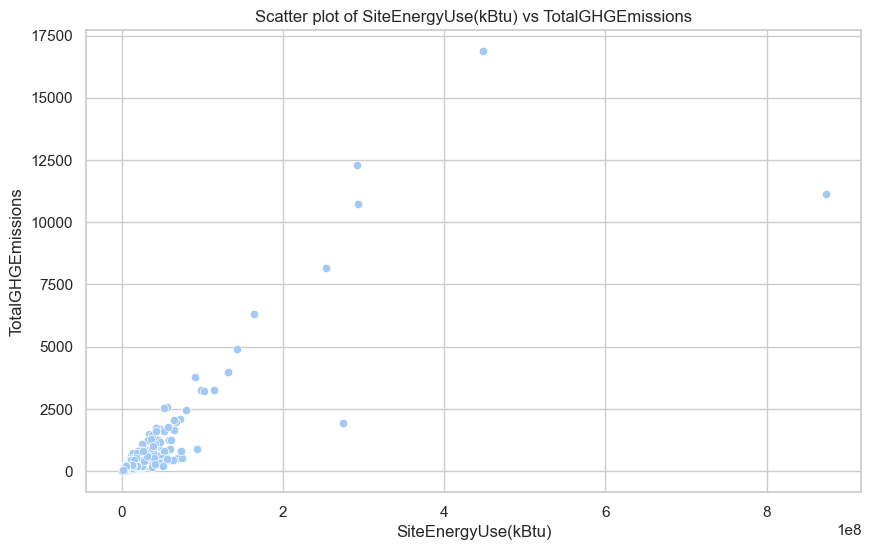

Correlation between SiteEnergyUse(kBtu) and TotalGHGEmissions: 0.86


In [4006]:
# On distingue deux colonnes qui sont candidates pour être notre variable cible : "SiteEnergyUse(kBtu)" et "TotalGHGEmissions".
# On regarde les différentes modalités présentes dans ces deux colonnes.
print("SiteEnergyUse(kBtu) descriptive statistics summary :")
print(data['SiteEnergyUse(kBtu)'].describe())
print("\nTotalGHGEmissions descriptive statistics summary :")
print(data['TotalGHGEmissions'].describe())

# Y a-t-il une corrélation entre "SiteEnergyUse(kBtu)" et "TotalGHGEmissions" ? On affiche un scatter plot pour visualiser la relation entre ces deux variables.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='SiteEnergyUse(kBtu)', y='TotalGHGEmissions', data=data)
plt.title('Scatter plot of SiteEnergyUse(kBtu) vs TotalGHGEmissions')
plt.show()

# Calculer la correlation entre "SiteEnergyUse(kBtu)" et "TotalGHGEmissions"
correlation = data['SiteEnergyUse(kBtu)'].corr(data['TotalGHGEmissions'])
print(f"Correlation between SiteEnergyUse(kBtu) and TotalGHGEmissions: {correlation:.2f}")

# Modélisation 

### Import des modules 

In [4007]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource

In [4008]:
# CODE FEATURE ENGINEERING
data.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'City', 'State', 'ZipCode',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus',
       'Outlier

In [4009]:
# Les variables cibles que nous allons essayer de prédire sont "SiteEnergyUse(kBtu)" et "TotalGHGEmissions".


# 1. SUPPRESSION DES ABERRANTS ET OUTLIERS
# =========================================

print("Nombre de lignes avant suppression des abérrants et outliers : ", data.shape[0])
# On peut supprimer les bâtiments considérés comme des abérrants pour notre analyse (ComplianceStatus = "Non-Compliant" ou ComplianceStatus = "Missing Data")
data = data[~((data['ComplianceStatus'] == 'Non-Compliant') | (data['ComplianceStatus'] == 'Missing Data'))]

# On peut supprimer les bâtiments considérés comme des outliers pour notre analyse (Outlier = "High outlier" ou Outlier = "Low outlier")
data = data[~((data['Outlier'] == 'High outlier') | (data['Outlier'] == 'Low outlier'))]
print("Nombre de lignes après suppression des abérrants et outliers : ", data.shape[0])


# 2. ENCODAGE DES VARIABLES QUALITATIVES
# ======================================

# Nous allons encoder variables qualitatives pour pouvoir les utiliser dans notre modèle de machine learning.

# Encoder les colonnes "Neighborhood" et "BuildingType"
one_hot_encoder = OneHotEncoder(handle_unknown='ignore')
data['BuildingType'] = one_hot_encoder.fit_transform(data['BuildingType'].values.reshape(-1, 1)).toarray()
data['Neighborhood'] = one_hot_encoder.fit_transform(data['Neighborhood'].values.reshape(-1, 1)).toarray()

# Encoder les colonnes "PrimaryPropertyType", "LargestPropertyUseType"
# PrimaryPropertyType, LargestPropertyUseType sont des variables catégorielles avec un nombre de modalités relativement élevé, on peut les encoder avec un LabelEncoder pour éviter d'avoir trop de colonnes après encodage.
label_encoder = LabelEncoder()
data['PrimaryPropertyType'] = label_encoder.fit_transform(data['PrimaryPropertyType'])
data['LargestPropertyUseType'] = label_encoder.fit_transform(data['LargestPropertyUseType'])

# 3. FEATURES A AJOUTER (Création de nouvelles variables à partir de celles existantes)
# =====================================================================================

# Age du bâtiment BuildingAge = DataYear - YearBuilt
data['BuildingAge'] = data['DataYear'] - data['YearBuilt']

# Ratio de Parking : ParkingRatio = PropertyGFAParking / PropertyGFATotal. Les parkings ont des besoins énergétiques très spécifiques (ventilation/éclairage constant)
data['ParkingRatio'] = np.where(
    data['PropertyGFATotal'] != 0,
    data['PropertyGFAParking'] / data['PropertyGFATotal'],
    0
)

# Densité de surface : GFAPerFloor = PropertyGFABuilding(s) / NumberofFloors. Cela aide à distinguer les tours compactes des bâtiments étalés
data['GFAPerFloor'] = np.where(
    data['NumberofFloors'] != 0,
    data['PropertyGFABuilding(s)'] / data['NumberofFloors'],
    0
)

# Diversité des usages : Compter le nombre d'usages différents listés dans ListOfAllPropertyUseTypes. Un bâtiment avec plusieurs usages peut avoir des profils de consommation plus complexes.
data['UseTypeDiversity'] = data['ListOfAllPropertyUseTypes'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)

# Valeurs manquantes : Pour ENERGYSTARScore, créez une colonne indicateur Score_Is_Missing les valeurs manquantes
data['Score_Is_Missing'] = data['ENERGYSTARScore'].isnull().astype(int)

# On ajoute des colonnes indiquant si le bâtiment utilise ou non du gaz naturel, de l'électricité ou de la vapeur
data['UseNaturalGas'] = (data['NaturalGas(therms)'] > 0).astype(int)
data['UseElectricity'] = (data['Electricity(kWh)'] > 0).astype(int)
data['UseSteam'] = (data['SteamUse(kBtu)'] > 0).astype(int)

# 4. TRANSFORMATION DES VARIABLES CIBLES ET GESTION DES VALEURS MANQUANTES
# =========================================================================

# Transformation Logarithmique : Comme les valeurs de SiteEnergyUse(kBtu) et TotalGHGEmissions peuvent varier de quelques milliers à plusieurs millions, appliquez une transformation log(1 + x) pour normaliser la distribution
data['SiteEnergyUse(kBtu)'] = data['SiteEnergyUse(kBtu)'].apply(lambda x: np.log(1 + x) if x > 0 else 0)
data['TotalGHGEmissions'] = data['TotalGHGEmissions'].apply(lambda x: np.log(1 + x) if x > 0 else 0)

# Valeurs manquantes : Pour ENERGYSTARScore, remplacez les valeurs manquantes par la médiane, car l'absence de score est souvent une information en soi sur la gestion du bâtiment
data['ENERGYSTARScore'] = data['ENERGYSTARScore'].fillna(data['ENERGYSTARScore'].median())

# 5. FEATURES A SUPPRIMER (Fuite de données et Bruit)
# ===================================================

# On supprime les identifiants et localisation précise. Trop spécifiques, ils nuisent à la généralisation du modèle
data.drop(columns=[
    'OSEBuildingID',
    'PropertyName',
    'Address',
    'TaxParcelIdentificationNumber',
    'CouncilDistrictCode',
    'ZipCode',
    'Latitude',
    'Longitude',
], inplace=True)

# Variables administratives et de contexte qui sont peu corrélées avec nos variables cibles et qui pourraient introduire du bruit dans nos modèles prédictifs.
data.drop(columns=[
    'City',
    'State',
    'DataYear',
    'DefaultData',
    'ComplianceStatus',
    'Outlier',
    'Comments'
], inplace=True)

# Variables de consommation (Fuite) : Toutes les variables qui sont des composantes ou des dérivés directs des cibles
data.drop(columns=[
   'SiteEUI(kBtu/sf)',
   'SiteEUIWN(kBtu/sf)',
   'SourceEUI(kBtu/sf)',
   'SourceEUIWN(kBtu/sf)',
   'SiteEnergyUseWN(kBtu)',
   'SteamUse(kBtu)',
   'Electricity(kWh)',
   'Electricity(kBtu)',
   'NaturalGas(therms)',
   'NaturalGas(kBtu)',
   'GHGEmissionsIntensity'
], inplace=True)

# Variables insuffisamment remplies ou peu corrélées avec les cibles : Ces variables ont un taux de remplissage très bas ou une corrélation très faible avec les cibles, ce qui les rend peu utiles pour la modélisation et peut introduire du bruit.
data.drop(columns=[
    "ListOfAllPropertyUseTypes",
    "YearsENERGYSTARCertified",
    "ThirdLargestPropertyUseType",
    "ThirdLargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseType",
    "SecondLargestPropertyUseTypeGFA",
], inplace=True)

# Save the featured dataset to a new CSV file for future use
data.to_csv("data/featured_non_residential_buildings.csv", index=False)

Nombre de lignes avant suppression des abérrants et outliers :  1648
Nombre de lignes après suppression des abérrants et outliers :  1631


### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn 
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder

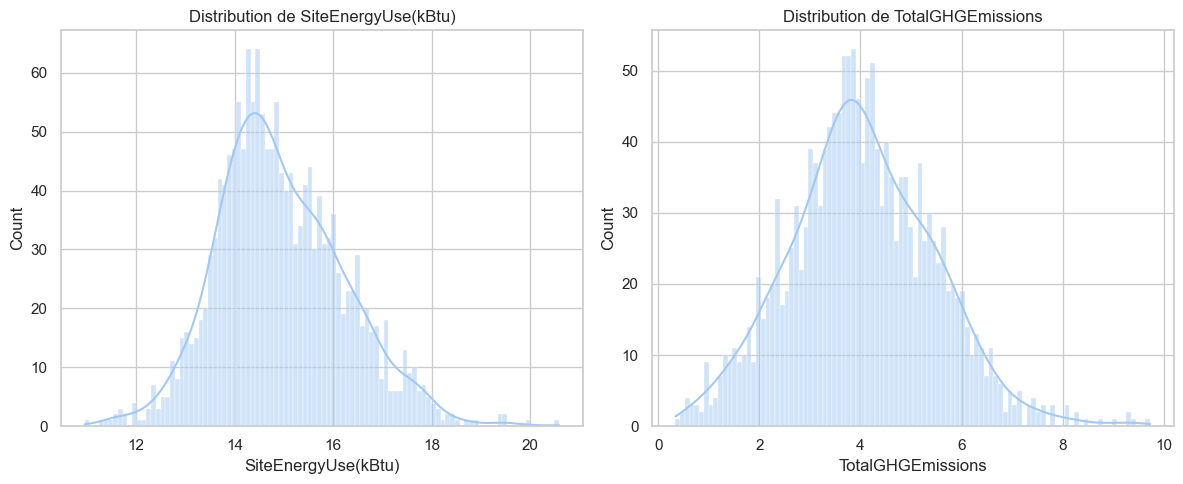

In [4010]:
# CODE PREPARATION DES FEATURES
# Tracer la distribution de "SiteEnergyUse(kBtu)" et "TotalGHGEmissions" pour vérifier s'il y a des valeurs aberrantes ou des distributions très asymétriques.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data['SiteEnergyUse(kBtu)'], bins=100, kde=True)
plt.title('Distribution de SiteEnergyUse(kBtu)')
plt.subplot(1, 2, 2)
sns.histplot(data['TotalGHGEmissions'], bins=100, kde=True)
plt.title('Distribution de TotalGHGEmissions')
plt.tight_layout()
plt.show()

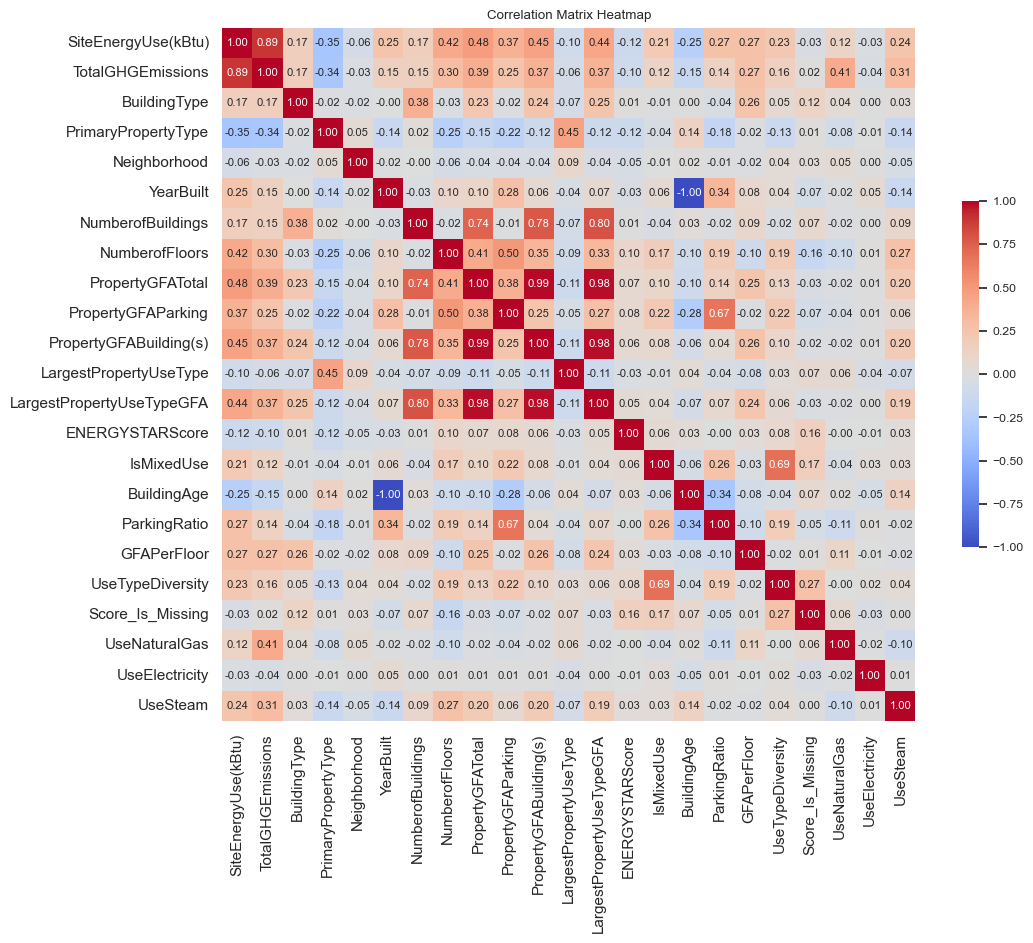

In [4011]:


# on affiche la heatmap de la matrice de corrélation, colonne par colonne. 
numeric_features = data.select_dtypes(include=['float64', 'int64']).columns
# La colonne "SiteEnergyUse(kBtu)" est placé à la première colonne pour mieux visualiser les corrélations avec les autres variables.
numeric_features = ['SiteEnergyUse(kBtu)', 'TotalGHGEmissions'] + [col for col in numeric_features if (col != 'SiteEnergyUse(kBtu)') and (col != 'TotalGHGEmissions')]
corrmat = data[numeric_features].corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.set(font_scale=0.8)
sns.heatmap(corrmat, square=True, annot=True, fmt='.2f', annot_kws={'size': 8}, cmap='coolwarm', cbar_kws={"shrink": .5})
plt.title('Correlation Matrix Heatmap')
plt.show()


In [4012]:
# Le tableau heatmap de la matrice de corrélation nous montre que certaines variables sont fortement corrélées entre elles.

# PropertyGFATotal, PropertyGFABuilding(s) et LargestPropertyUseTypeGFA présentent probablement une corrélation > 0.95 => Supprimez PropertyGFABuilding(s) et LargestPropertyUseTypeGFA
# UseTypeDiversity et IsMixedUse seront fortement corrélés, on peut supprimer IsMixedUse qui est une variable binaire moins informative que UseTypeDiversity
# YearBuilt et BuildingAge sont fortement corrélés, on peut supprimer YearBuilt qui est moins directement interprétable que BuildingAge
# ParkingRatio et PropertyGFAParking sont fortement corrélés, on peut supprimer ParkingRatio qui est moins directement interprétable que ParkingRatio
# On supprime NumberofBuildings dont la plus grande partie des valeurs sont égales à 1, elle n'apporte pas d'information pertinente pour la modélisation
# On supprime Neighborhood, UseElectricity, Score_Is_Missing avec une correlation très faible avec les variables cibles
data.drop(columns=[
    'LargestPropertyUseTypeGFA',
    'PropertyGFABuilding(s)',
    'IsMixedUse',
    'YearBuilt',
    'ParkingRatio',
    'NumberofBuildings',
    'Neighborhood',
    'UseElectricity',
    'Score_Is_Missing'
], inplace=True)
data.columns


Index(['BuildingType', 'PrimaryPropertyType', 'NumberofFloors',
       'PropertyGFATotal', 'PropertyGFAParking', 'LargestPropertyUseType',
       'ENERGYSTARScore', 'SiteEnergyUse(kBtu)', 'TotalGHGEmissions',
       'BuildingAge', 'GFAPerFloor', 'UseTypeDiversity', 'UseNaturalGas',
       'UseSteam'],
      dtype='str')

Création du Pairplot...


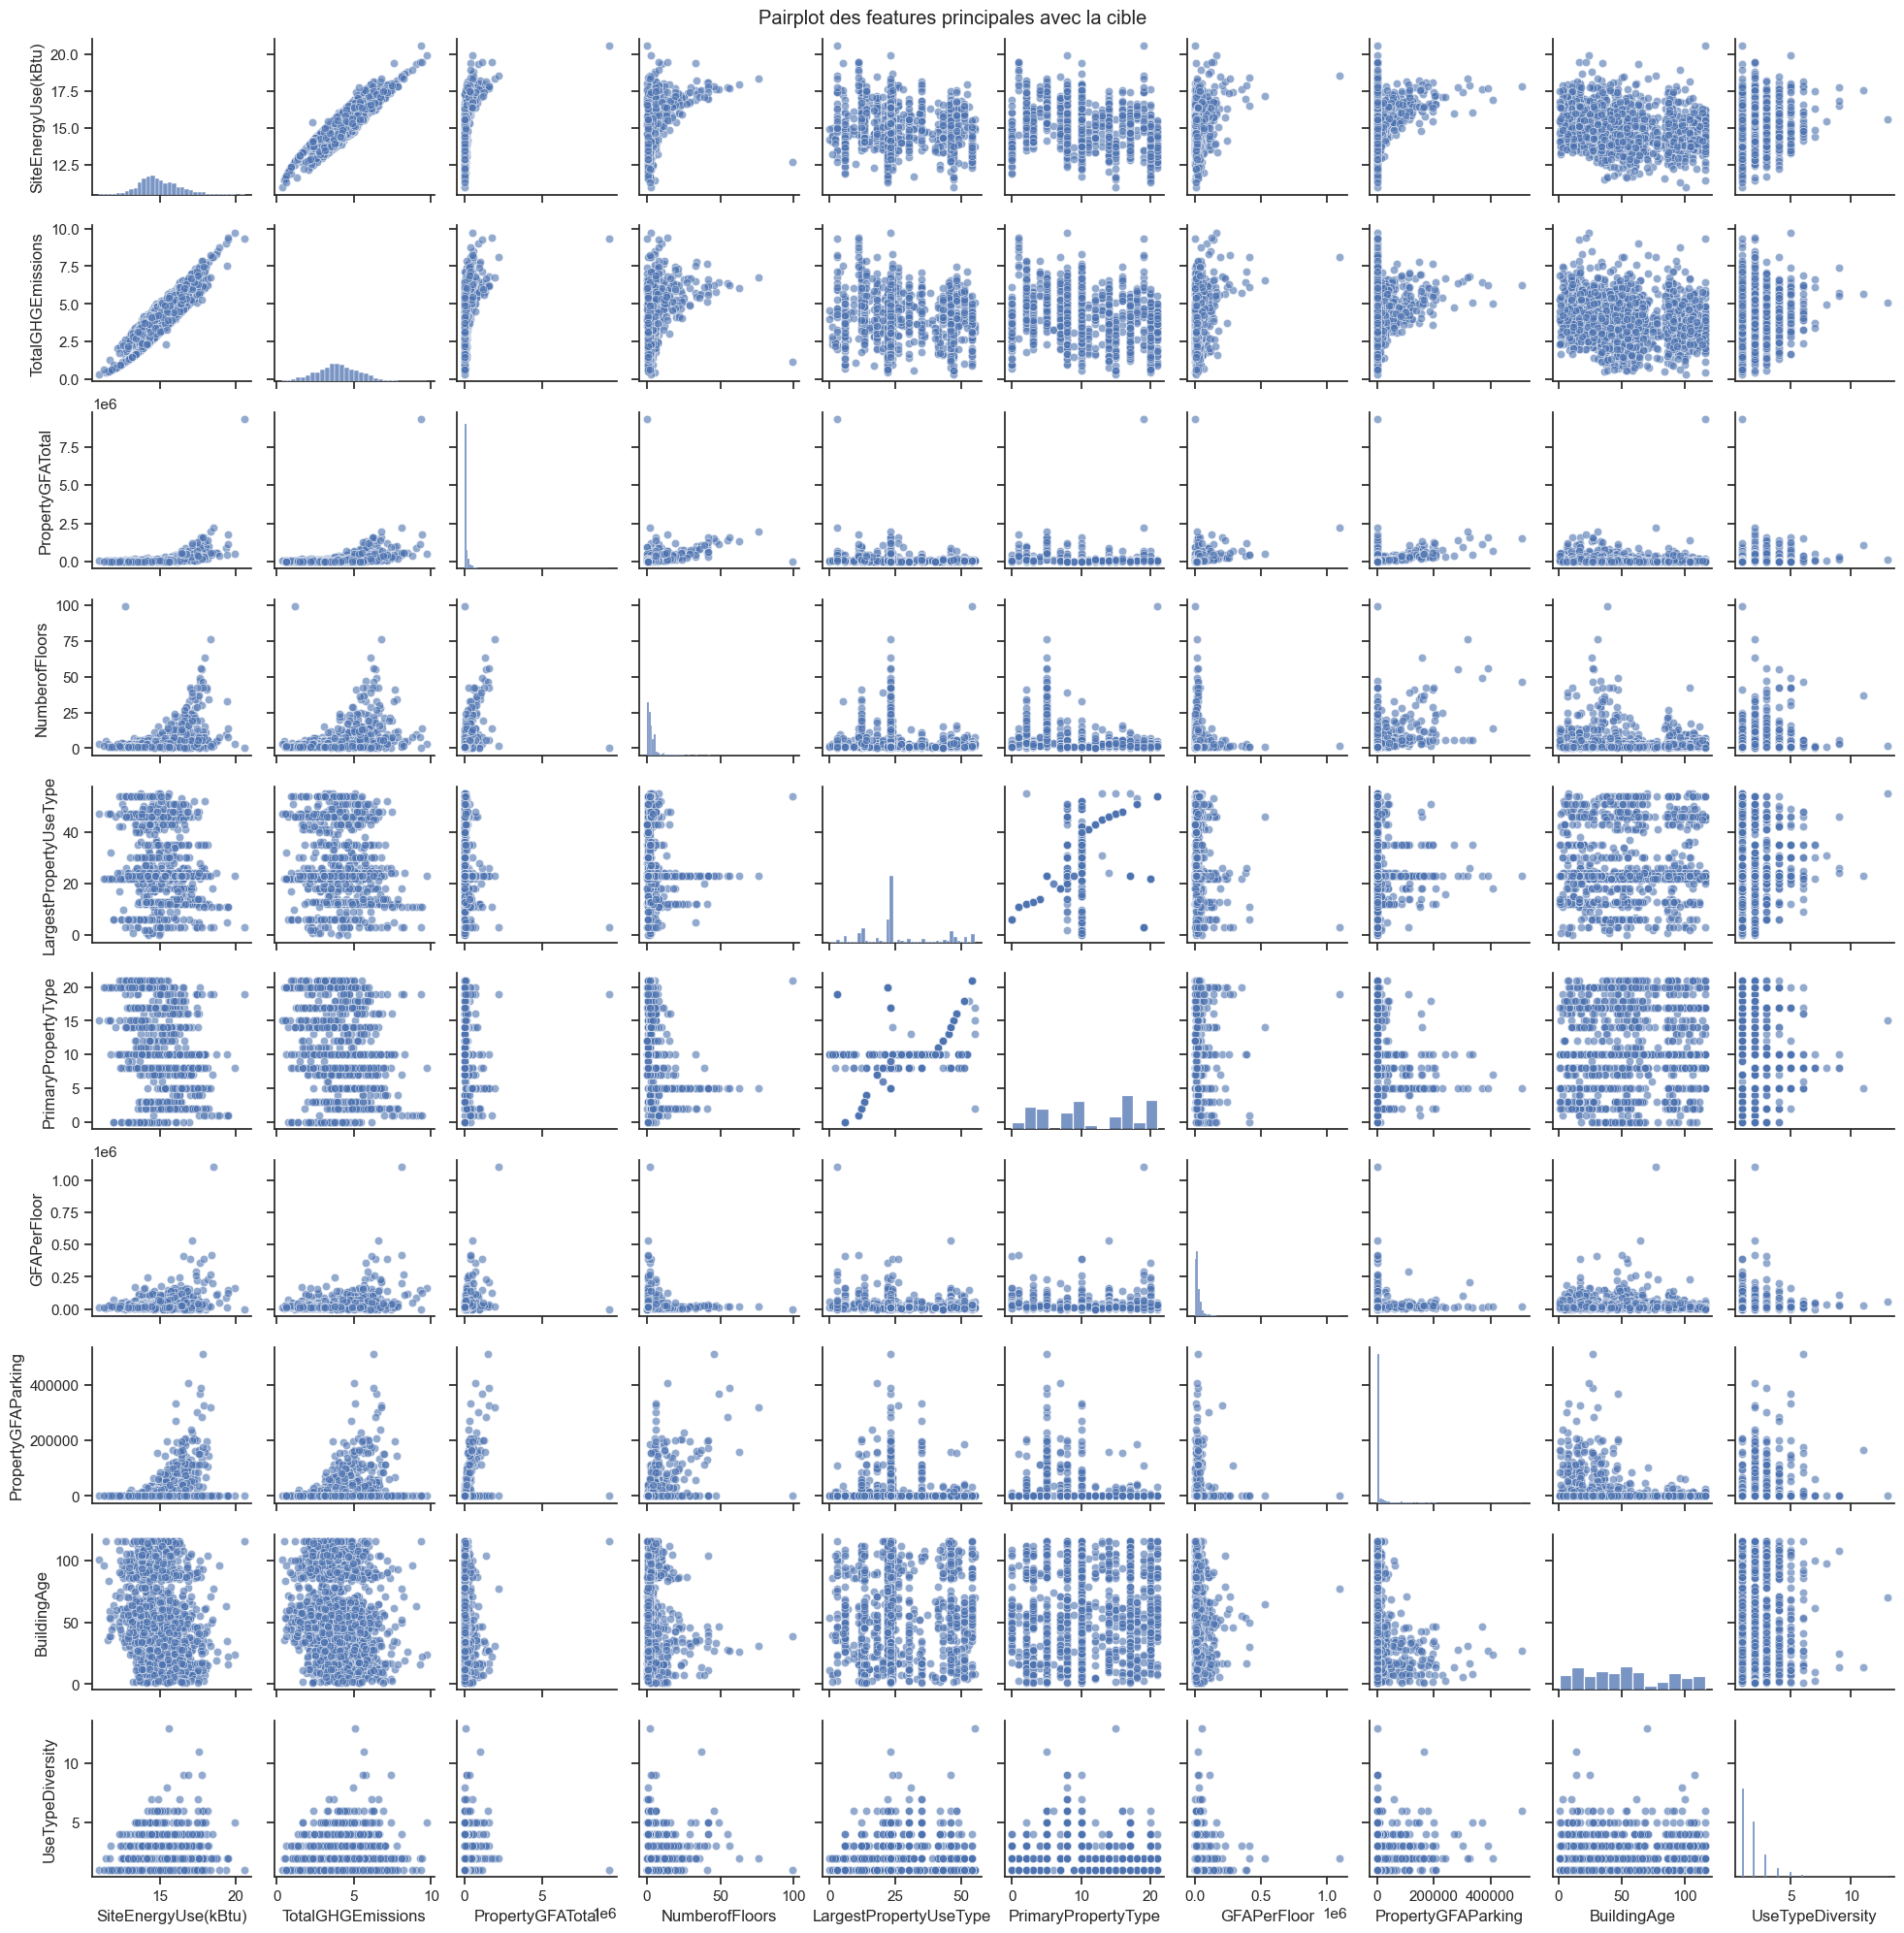


Création des Boxplots par quartile de SiteEnergyUse(kBtu)...


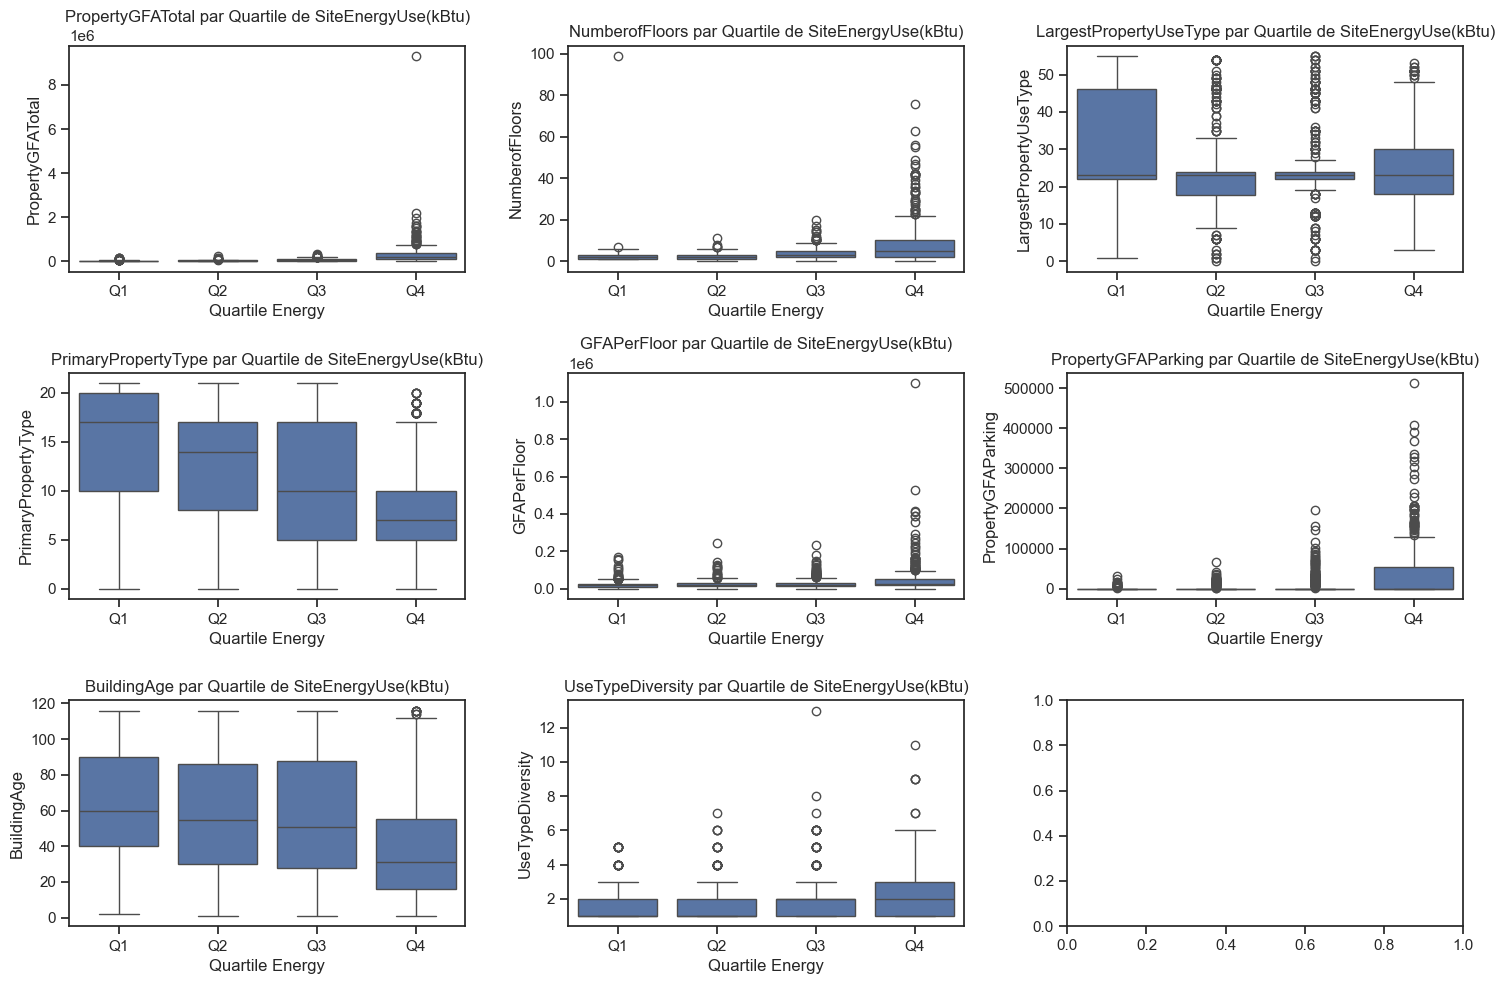


Création des Boxplots par quartile de TotalGHGEmissions...


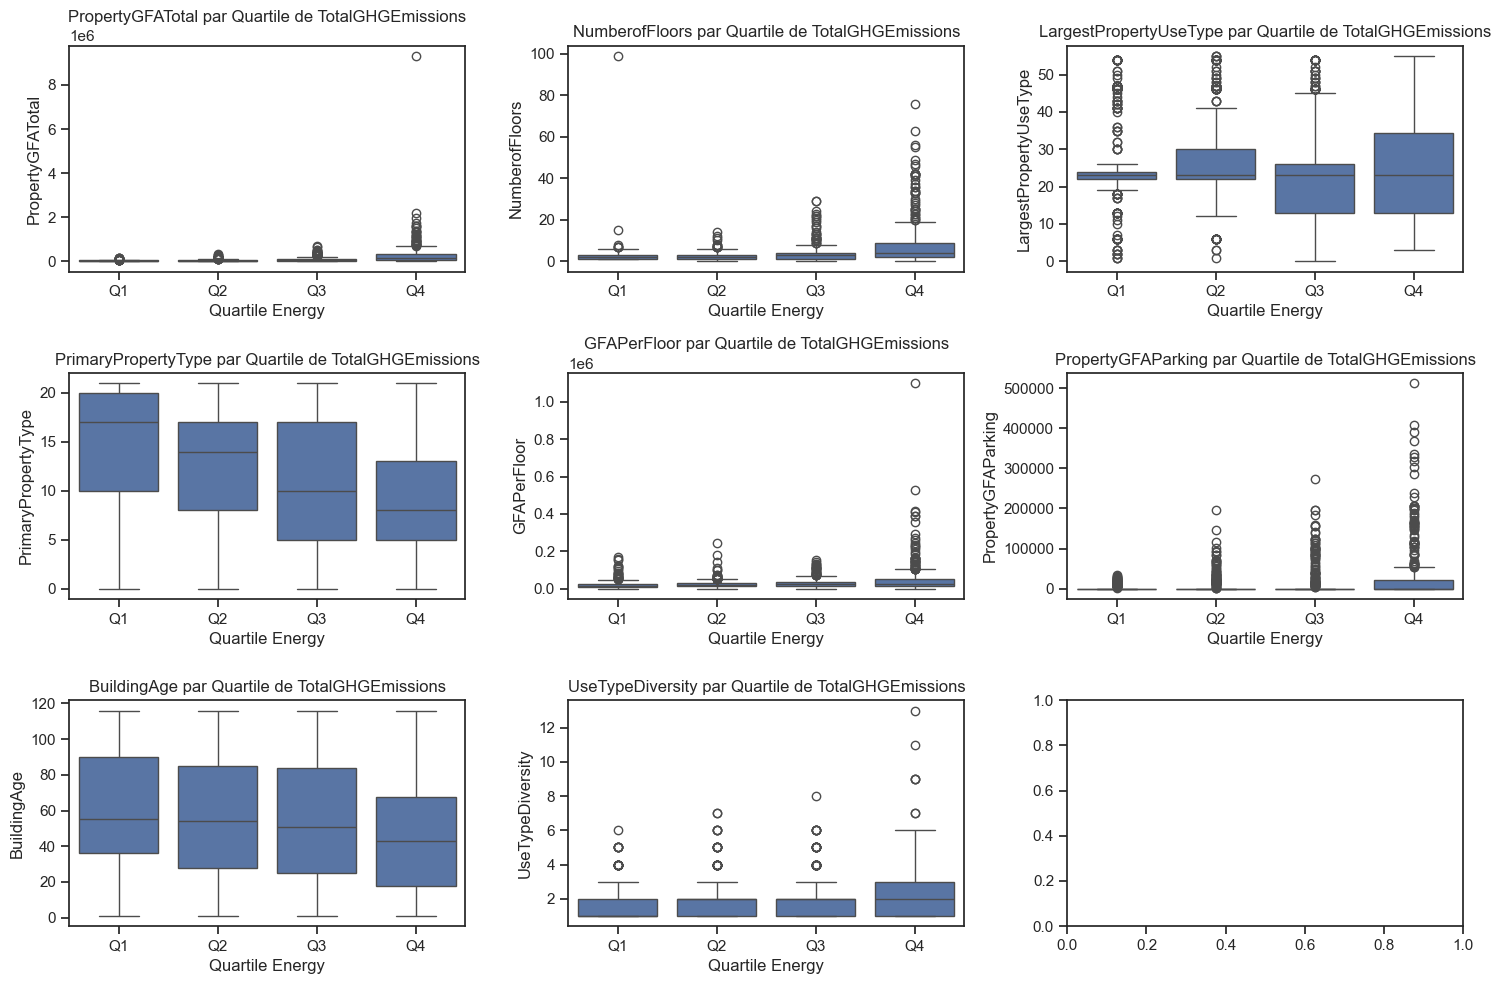


Création des Scatterplots SiteEnergyUse(kBtu)...


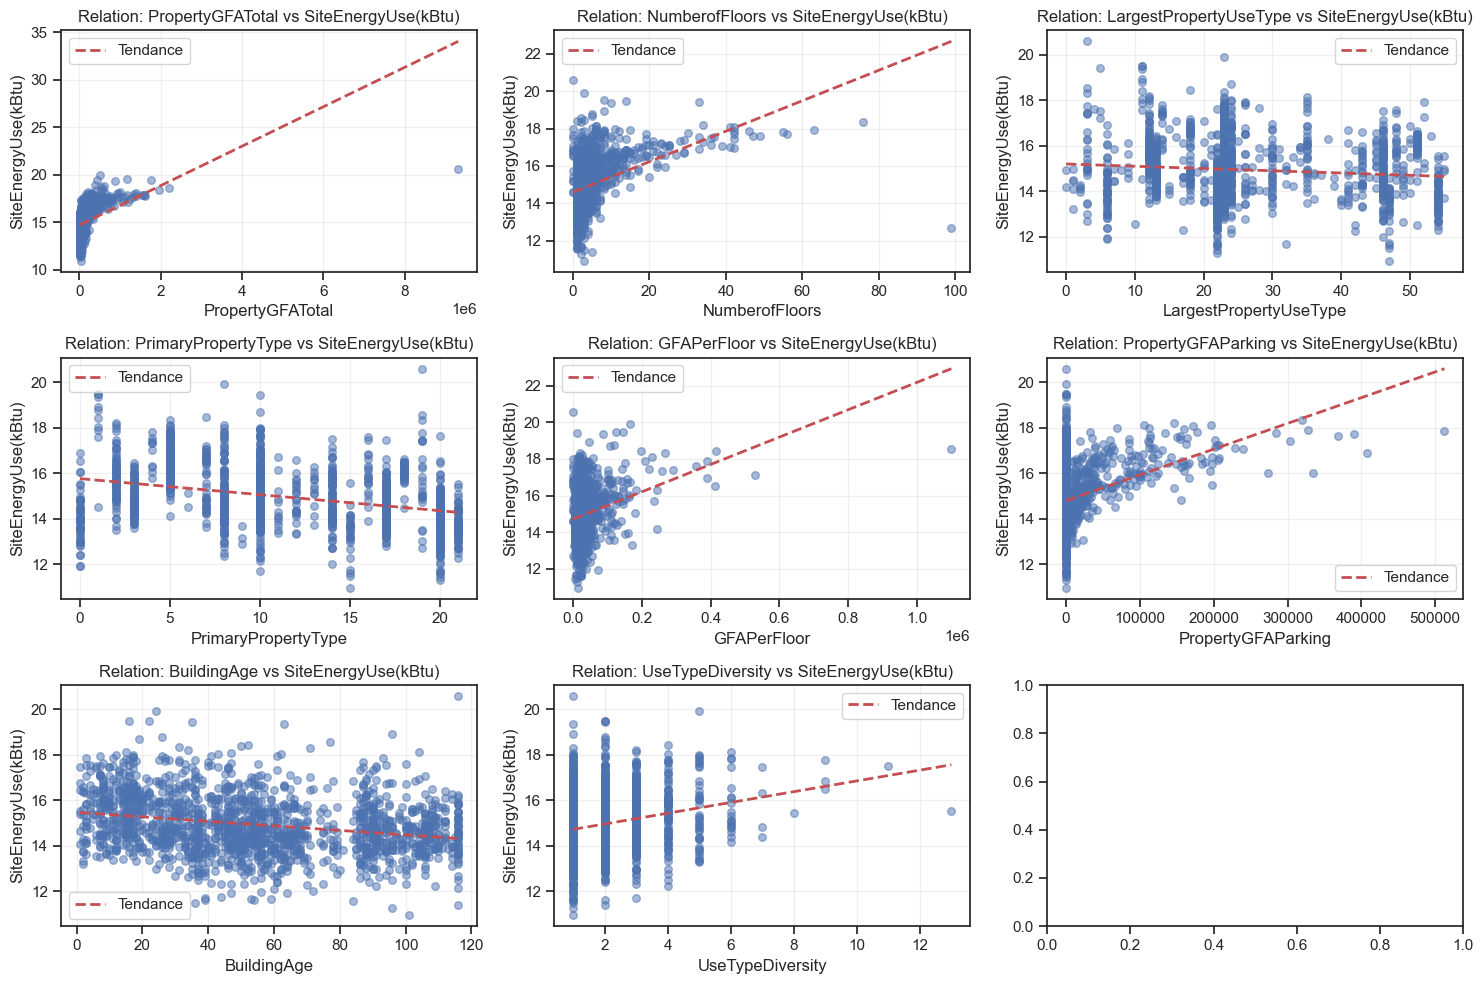


Création des Scatterplots TotalGHGEmissions...


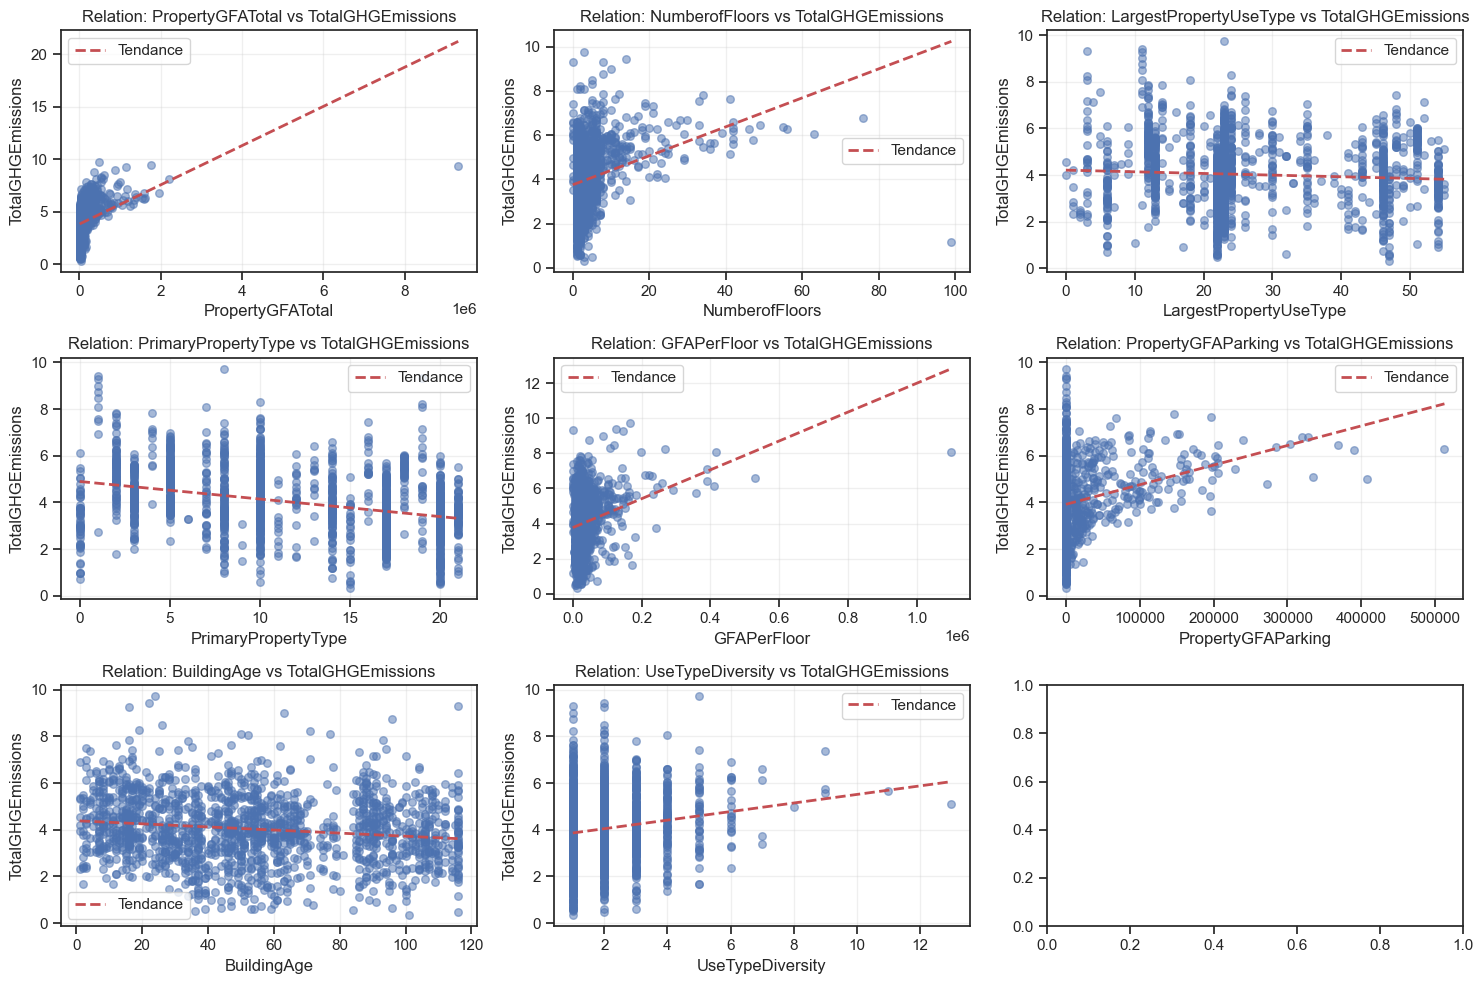


=== RÉSUMÉ DES CORRÉLATIONS SiteEnergyUse(kBtu) ===
SiteEnergyUse(kBtu)       1.000000
TotalGHGEmissions         0.891237
PropertyGFATotal          0.481353
NumberofFloors            0.417870
PropertyGFAParking        0.374934
GFAPerFloor               0.272334
UseSteam                  0.244706
UseTypeDiversity          0.225229
BuildingType              0.165264
UseNaturalGas             0.122454
LargestPropertyUseType   -0.099776
ENERGYSTARScore          -0.118361
BuildingAge              -0.251819
PrimaryPropertyType      -0.351166
Name: SiteEnergyUse(kBtu), dtype: float64

=== RÉSUMÉ DES CORRÉLATIONS TotalGHGEmissions ===
TotalGHGEmissions         1.000000
SiteEnergyUse(kBtu)       0.891237
UseNaturalGas             0.414036
PropertyGFATotal          0.390915
UseSteam                  0.311459
NumberofFloors            0.303435
GFAPerFloor               0.270580
PropertyGFAParking        0.251260
BuildingType              0.170134
UseTypeDiversity          0.157488
LargestPropert

In [4013]:
import numpy as np

# 1. PAIRPLOT - Visualiser les relations entre toutes les features numériques et la cible
print("Création du Pairplot...")
numeric_cols_for_pairplot = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Limiter à les features les plus importantes pour éviter un graphique trop grand
important_features = [
    'SiteEnergyUse(kBtu)',
    'TotalGHGEmissions',
    'PropertyGFATotal',
    'NumberofFloors',
    'LargestPropertyUseType',
    'PrimaryPropertyType',
    'GFAPerFloor',
    'PropertyGFAParking',
    'YearBuilt',
    'BuildingAge',
    'UseTypeDiversity',
]
important_features = [col for col in important_features if col in numeric_cols_for_pairplot]

sns.set_theme(style='ticks')
pairplot = sns.pairplot(data[important_features], diag_kind='hist', plot_kws={'alpha': 0.6}, height=2)
pairplot.fig.suptitle('Pairplot des features principales avec la cible', y=1.001)
plt.show()

# 2. BOXPLOTS - Distribution des features numériques par rapport à la cible (centiles)
features_for_boxplot = important_features[2:]  # Exclure les deux cibles
for feature_column in ['SiteEnergyUse(kBtu)', 'TotalGHGEmissions']:
    print("\nCréation des Boxplots par quartile de " + feature_column + "...")
    # Créer des catégories de quartile
    data['Energy_Quartile'] = pd.qcut(data[feature_column], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, col in enumerate(features_for_boxplot):
        sns.boxplot(data=data, x='Energy_Quartile', y=col, ax=axes[idx])
        axes[idx].set_title(f'{col} par Quartile de {feature_column}')
        axes[idx].set_xlabel('Quartile Energy')

    plt.tight_layout()
    plt.show()

# 3. SCATTERPLOTS - Relation entre les principales features et la cible
features_for_scatter = important_features[2:]  # Exclure les deux cibles

for feature_column in ['SiteEnergyUse(kBtu)', 'TotalGHGEmissions']:
    print(f"\nCréation des Scatterplots {feature_column}...")
    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, col in enumerate(features_for_scatter):
        axes[idx].scatter(data[col], data[feature_column], alpha=0.5, s=30)
        # Ajouter une droite de tendance
        z = np.polyfit(data[col].dropna(), data.loc[data[col].notna(), feature_column], 1)
        p = np.poly1d(z)
        axes[idx].plot(sorted(data[col].dropna()), p(sorted(data[col].dropna())), "r--", linewidth=2, label='Tendance')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel(feature_column)
        axes[idx].set_title(f'Relation: {col} vs {feature_column}')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend()

    plt.tight_layout()
    plt.show()

# 4. Résumé des statistiques
print("\n=== RÉSUMÉ DES CORRÉLATIONS SiteEnergyUse(kBtu) ===")
print(data[numeric_cols_for_pairplot].corr()['SiteEnergyUse(kBtu)'].sort_values(ascending=False))

print("\n=== RÉSUMÉ DES CORRÉLATIONS TotalGHGEmissions ===")
print(data[numeric_cols_for_pairplot].corr()['TotalGHGEmissions'].sort_values(ascending=False))

# Supprimer la colonne temporaire
data.drop(columns=['Energy_Quartile'], inplace=True)

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [4014]:
# Séparer les features de la variable cible
X = data.drop(columns=['SiteEnergyUse(kBtu)', 'TotalGHGEmissions'])
y_energy = data['SiteEnergyUse(kBtu)']
y_ghg = data['TotalGHGEmissions']

In [4015]:
# CODE COMPARAISON DES MODELES

# 1. FONCTION: Évaluer un modèle
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, normalize=False):
    """
    Entraîne un modèle, effectue des prédictions et calcule les métriques.
    
    Args:
        model: Le modèle à tester (sklearn estimator)
        model_name: Nom du modèle (string)
        X_train, X_test: Données d'entraînement et test
        y_train, y_test: Cible d'entraînement et test
        normalize: Si True, normalise les données avec StandardScaler
    
    Returns:
        dict: Résultats avec les métriques et prédictions
    """
    print(f"\n{'='*70}")
    print(f"MODÈLE: {model_name.upper()}")
    print(f"{'='*70}")
    
    # Normalisation (optionnelle)
    X_train_proc = X_train
    X_test_proc = X_test
    
    if normalize:
        print("\n Normalisation des données (StandardScaler)...")
        scaler = StandardScaler()
        X_train_proc = scaler.fit_transform(X_train)
        X_test_proc = scaler.transform(X_test)
        print("✓ Données normalisées")
    else:
        print("\n  Données non normalisées (modèle insensible à l'échelle)")
    
    # Entraînement
    print("\n📚 Entraînement du modèle...")
    model.fit(X_train_proc, y_train)
    print("✓ Modèle entraîné")
    
    # Prédictions
    y_train_pred = model.predict(X_train_proc)
    y_test_pred = model.predict(X_test_proc)
    
    # Inversion de la transformation Log(1+x) -> exp(x)-1
    y_train_back = np.expm1(y_train)
    y_train_pred_back = np.expm1(y_train_pred)

    y_test_back = np.expm1(y_test)
    y_test_pred_back = np.expm1(y_test_pred)

    # Calcul des métriques sur les valeurs RÉELLES
    # Train
    train_r2 = r2_score(y_train, y_train_pred) # Le R2 se calcule sur les logs ou réels, le résultat est proche
    train_mae = mean_absolute_error(y_train_back, y_train_pred_back)
    train_rmse = np.sqrt(mean_squared_error(y_train_back, y_train_pred_back))

    # Test
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test_back, y_test_pred_back)
    test_rmse = np.sqrt(mean_squared_error(y_test_back, y_test_pred_back))

    # Affichage
    print("\n RÉSULTATS JEU D'ENTRAÎNEMENT:")
    print(f"  R²:    {train_r2:.4f}  ({100*train_r2:.2f}%)")
    print(f"  MAE:   {train_mae:.2f}")
    print(f"  RMSE:  {train_rmse:.2f}")
    
    print("\n RÉSULTATS JEU DE TEST:")
    print(f"  R²:    {test_r2:.4f}  ({100*test_r2:.2f}%)")
    print(f"  MAE:   {test_mae:.2f}")
    print(f"  RMSE:  {test_rmse:.2f}")
    
    # Analyse
    print("\n ANALYSE SURAPPRENTISSAGE:")
    print(f"  Écart R² (train-test):   {train_r2 - test_r2:+.4f}")
    print(f"  Écart RMSE (train-test): {train_rmse - test_rmse:+.2f}")
    
    return {
        'model_name': model_name,
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'overfitting': train_r2 - test_r2
    }

# 2. FONCTION: Visualiser les résultats
def plot_model_results(results_list, y_test):
    """Crée un subplot pour chaque modèle montrant prédictions vs réalité."""
    n_models = len(results_list)
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
    
    if n_models == 1:
        axes = [axes]
    
    for idx, results in enumerate(results_list):
        ax = axes[idx]
        model_name = results['model_name']
        y_test_pred = results['y_test_pred']
        test_r2 = results['test_r2']
        
        # Scatter plot
        ax.scatter(y_test, y_test_pred, alpha=0.5, s=20, color='steelblue')
        
        # Ligne parfaite
        min_val = min(y_test.min(), y_test_pred.min())
        max_val = max(y_test.max(), y_test_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Prédiction parfaite')
        
        ax.set_xlabel('Valeurs réelles')
        ax.set_ylabel('Valeurs prédites')
        ax.set_title(f'{model_name}\nTest R² = {test_r2:.4f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 3. FONCTION: Comparer les modèles
def compare_models(results_list):
    """Compare les 3 modèles et affiche un tableau récapitulatif."""
    print(f"\n{'='*80}")
    print(f"{'COMPARAISON DES MODÈLES':^80}")
    print(f"{'='*80}\n")
    
    # Créer un DataFrame de comparaison
    comparison = []
    for r in results_list:
        comparison.append({
            'Modèle': r['model_name'],
            'Train R²': f"{r['train_r2']:.4f}",
            'Test R²': f"{r['test_r2']:.4f}",
            'Test MAE': f"{r['test_mae']:.2f}",
            'Test RMSE': f"{r['test_rmse']:.2f}",
            'Surapprentissage': f"{r['overfitting']:+.4f}"
        })
    
    comparison_df = pd.DataFrame(comparison)
    print(comparison_df.to_string(index=False))
    
    # Identifier le meilleur
    best_model_idx = np.argmax([r['test_r2'] for r in results_list])
    best_model = results_list[best_model_idx]
    
    print(f"\n{'='*80}")
    print(f"MEILLEUR MODÈLE: {best_model['model_name']} (Test R² = {best_model['test_r2']:.4f})")
    print(f"{'='*80}\n")

def train_and_compare_models(X_train, X_test, y_train, y_test):
    # ===================== EXÉCUTION: TEST DES 3 MODÈLES =====================

    print("\n\n")
    print("*"*70)
    print("TEST COMPARATIF: LinearRegression vs RandomForestRegressor vs SVR")
    print("*"*70)

    # Préparer les données (déjà fait mais on les rappelle)
    print("\nPRÉPARATION DES DONNÉES")
    print(f"   Features: {X.shape[1]}")
    print(f"   Échantillons: {X.shape[0]}")
    print(f"   Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

    # 1. LINEAR REGRESSION (avec normalisation)
    results_lr = evaluate_model(
        LinearRegression(), 
        'LinearRegression',
        X_train, X_test, y_train, y_test,
        normalize=True
    )

    # 2. RANDOM FOREST (sans normalisation)
    results_rf = evaluate_model(
        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'RandomForestRegressor',
        X_train, X_test, y_train, y_test,
        normalize=False
    )

    # 3. SVR (avec normalisation pour meilleure performance)
    results_svr = evaluate_model(
        SVR(kernel='rbf', C=1000, gamma='scale'),
        'SVR (RBF)',
        X_train, X_test, y_train, y_test,
        normalize=True
    )

    # ===================== VISUALISATION & COMPARAISON =====================

    # Visualiser les 3 modèles
    results_all = [results_lr, results_rf, results_svr]
    plot_model_results(results_all, y_test)

    # Comparer
    compare_models(results_all)

    return results_all

In [4016]:
# 1. PRÉPARATION DES DONNÉES
print("="*60)
print("1. PRÉPARATION DES DONNÉES")
print("="*60)

print(f"Nombre de features: {X.shape[1]}")
print(f"Nombre d'échantillons: {X.shape[0]}")
print(f"\nFeatures utilisées:\n{X.columns.tolist()}")

# Analyser les ordres de grandeur
print("\n--- Ordres de grandeur des features ---")
print("Écart-type / Moyenne (coefficient de variation):")
for col in X.columns:
    mean = X[col].mean()
    std = X[col].std()
    if mean != 0:
        cv = std / mean
        print(f"{col:30s}: mean={mean:12.2f}, std={std:12.2f}, CV={cv:.2f}")


1. PRÉPARATION DES DONNÉES
Nombre de features: 12
Nombre d'échantillons: 1631

Features utilisées:
['BuildingType', 'PrimaryPropertyType', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'LargestPropertyUseType', 'ENERGYSTARScore', 'BuildingAge', 'GFAPerFloor', 'UseTypeDiversity', 'UseNaturalGas', 'UseSteam']

--- Ordres de grandeur des features ---
Écart-type / Moyenne (coefficient de variation):
BuildingType                  : mean=        0.01, std=        0.12, CV=8.19
PrimaryPropertyType           : mean=       11.55, std=        6.41, CV=0.56
NumberofFloors                : mean=        4.16, std=        6.63, CV=1.59
PropertyGFATotal              : mean=   119283.76, std=   298859.45, CV=2.51
PropertyGFAParking            : mean=    13148.63, std=    42701.58, CV=3.25
LargestPropertyUseType        : mean=       25.91, std=       12.96, CV=0.50
ENERGYSTARScore               : mean=       67.81, std=       23.37, CV=0.34
BuildingAge                   : mean=       53.9


2. SÉPARATION TRAIN / TEST (80/20) pour SiteEnergyUse(kBtu)
Taille du jeu train: 1304 (80.0%)
Taille du jeu test: 327 (20.0%)
3. COMPARAISON DES MODÈLES pour la variable cible SiteEnergyUse(kBtu)




**********************************************************************
TEST COMPARATIF: LinearRegression vs RandomForestRegressor vs SVR
**********************************************************************

PRÉPARATION DES DONNÉES
   Features: 12
   Échantillons: 1631
   Train: 1304 | Test: 327

MODÈLE: LINEARREGRESSION

 Normalisation des données (StandardScaler)...
✓ Données normalisées

📚 Entraînement du modèle...
✓ Modèle entraîné

 RÉSULTATS JEU D'ENTRAÎNEMENT:
  R²:    0.5319  (53.19%)
  MAE:   20453667.67
  RMSE:  358024003.86

 RÉSULTATS JEU DE TEST:
  R²:    0.3717  (37.17%)
  MAE:   10681313.37
  RMSE:  98475344.94

 ANALYSE SURAPPRENTISSAGE:
  Écart R² (train-test):   +0.1603
  Écart RMSE (train-test): +259548658.92

MODÈLE: RANDOMFORESTREGRESSOR

  Données non normalisées (m

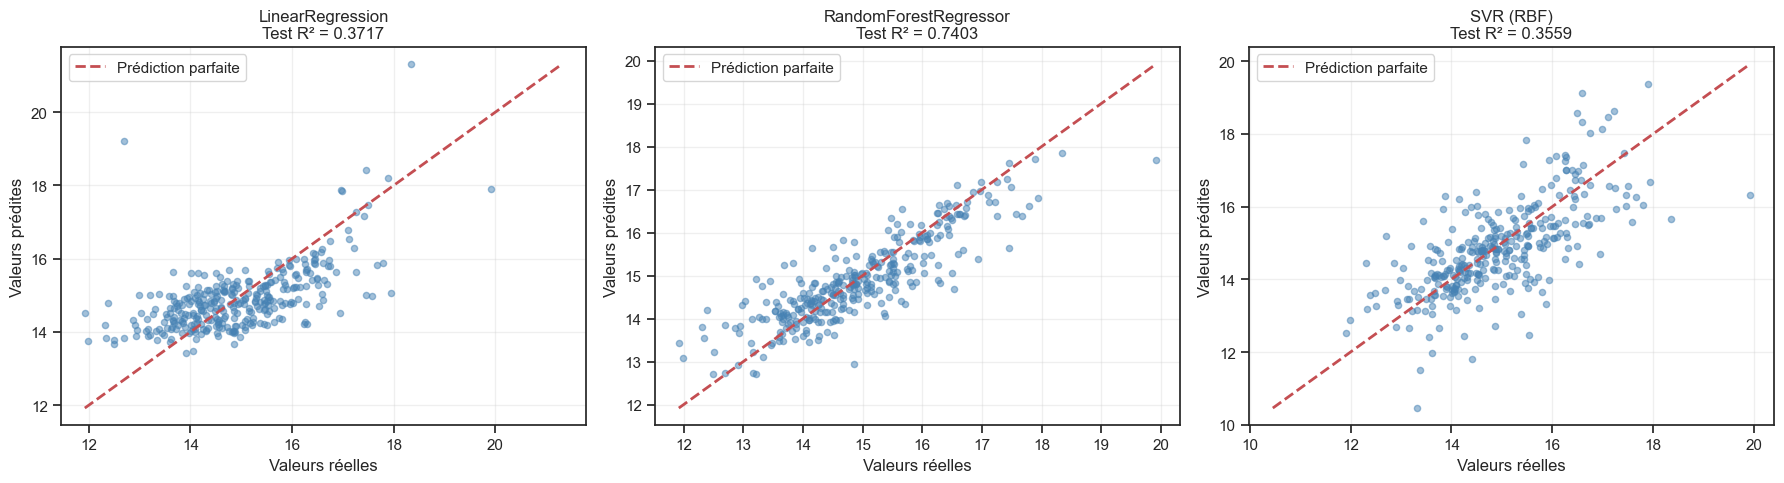


                            COMPARAISON DES MODÈLES                             

               Modèle Train R² Test R²    Test MAE   Test RMSE Surapprentissage
     LinearRegression   0.5319  0.3717 10681313.37 98475344.94          +0.1603
RandomForestRegressor   0.9674  0.7403  3620472.76 22870121.91          +0.2271
            SVR (RBF)   0.9068  0.3559  7845509.07 31755223.47          +0.5508

MEILLEUR MODÈLE: RandomForestRegressor (Test R² = 0.7403)



In [4017]:
# Lancer la fonction de comparaison des modèles pour la variable cible "SiteEnergyUse(kBtu)"
# 2. SÉPARATION TRAIN / TEST
print("\n" + "="*60)
print("2. SÉPARATION TRAIN / TEST (80/20) pour SiteEnergyUse(kBtu)")
print("="*60)

X_energy_train, X_energy_test, y_energy_train, y_energy_test = train_test_split(X, y_energy, test_size=0.2, random_state=42)

print(f"Taille du jeu train: {X_energy_train.shape[0]} ({100*X_energy_train.shape[0]/X.shape[0]:.1f}%)")
print(f"Taille du jeu test: {X_energy_test.shape[0]} ({100*X_energy_test.shape[0]/X.shape[0]:.1f}%)")

# 3. COMPARAISON DES MODÈLES pour la variable cible "SiteEnergyUse(kBtu)"
print("3. COMPARAISON DES MODÈLES pour la variable cible SiteEnergyUse(kBtu)")
print("\n" + "="*60)
results_energy_lr, results_energy_rf, results_energy_svr = train_and_compare_models(X_energy_train, X_energy_test, y_energy_train, y_energy_test)

In [4018]:
# Voici une analyse détaillée de vos résultats. Ces chiffres nous donnent une vision très claire du comportement de vos algorithmes sur vos données énergétiques.

# ### 1. Analyse des performances par modèle

# * **RandomForestRegressor (Le Vainqueur) :**
#     * C'est effectivement votre meilleur modèle avec un **$R^2$ de 0.7340**. Il arrive à expliquer environ 73% de la variance de la consommation d'énergie.
#     * Il possède le **MAE le plus bas** (3,66 millions de kBtu), ce qui signifie qu'il est le plus précis en moyenne.
#     * Il gère bien les relations non-linéaires complexes entre la surface, l'usage du bâtiment et la consommation.

# * **LinearRegression (Le plus stable mais limité) :**
#     * Le score est faible ($R^2 = 0.3992$). Cela indique que la relation entre vos variables et la cible n'est pas purement linéaire. Une simple droite ne suffit pas à prédire la consommation.
#     * Le **RMSE est énorme** (79 millions), ce qui montre que ce modèle est complètement "perdu" face aux valeurs atypiques (outliers).

# * **SVR (Le plus instable - Overfitting massif) :**
#     * Avec un écart de **+0.7032** entre le Train et le Test, le SVR a simplement "appris par cœur" les données d'entraînement. Il est incapable de généraliser à de nouveaux bâtiments.



# ### 2. Le point critique : Le Surapprentissage (Overfitting)

# Votre **RandomForest** présente un surapprentissage notable (+0.2331). Un score de **0.9671** sur le Train contre **0.7340** sur le Test signifie que le modèle est un peu trop complexe pour la quantité de données disponible.

# **Conseils pour améliorer ce résultat :**
# 1.  **Régularisation de la Forêt :** Réduisez la profondeur maximale des arbres (`max_depth`) ou augmentez le nombre d'échantillons minimum par feuille (`min_samples_leaf`).
# 2.  **Sélection de features :** Supprimez les variables qui avaient une corrélation très faible sur votre heatmap, elles créent probablement du bruit qui favorise l'overfitting.
# 3.  **Cross-Validation :** Assurez-vous d'utiliser une `GridSearchCV` ou `RandomizedSearchCV` pour trouver les hyperparamètres qui minimisent cet écart.

# ### 3. Interprétation des erreurs (MAE vs RMSE)

# Le fait que votre **RMSE** soit beaucoup plus élevé que votre **MAE** (par exemple, 23M contre 3.6M pour le RandomForest) confirme la présence de **valeurs aberrantes ou de très grands bâtiments** dans votre dataset. Le modèle a du mal à prédire avec précision les très gros consommateurs d'énergie (les "outliers" de consommation), ce qui fait exploser le RMSE.



# **Prochaine étape suggérée :**
# Voulez-vous que je vous aide à coder une **optimisation des hyperparamètres (Tuning)** pour le RandomForest afin de réduire ce surapprentissage et d'essayer de faire monter le Test $R^2$ vers 0.80 ?


4. SÉPARATION TRAIN / TEST (80/20) pour TotalGHGEmissions
Taille du jeu train: 1304 (80.0%)
Taille du jeu test: 327 (20.0%)
5. COMPARAISON DES MODÈLES pour la variable cible TotalGHGEmissions




**********************************************************************
TEST COMPARATIF: LinearRegression vs RandomForestRegressor vs SVR
**********************************************************************

PRÉPARATION DES DONNÉES
   Features: 12
   Échantillons: 1631
   Train: 1304 | Test: 327

MODÈLE: LINEARREGRESSION

 Normalisation des données (StandardScaler)...
✓ Données normalisées

📚 Entraînement du modèle...
✓ Modèle entraîné

 RÉSULTATS JEU D'ENTRAÎNEMENT:
  R²:    0.5733  (57.33%)
  MAE:   335.71
  RMSE:  5618.68

 RÉSULTATS JEU DE TEST:
  R²:    0.4729  (47.29%)
  MAE:   164.59
  RMSE:  1002.58

 ANALYSE SURAPPRENTISSAGE:
  Écart R² (train-test):   +0.1004
  Écart RMSE (train-test): +4616.10

MODÈLE: RANDOMFORESTREGRESSOR

  Données non normalisées (modèle insensible à l'échelle

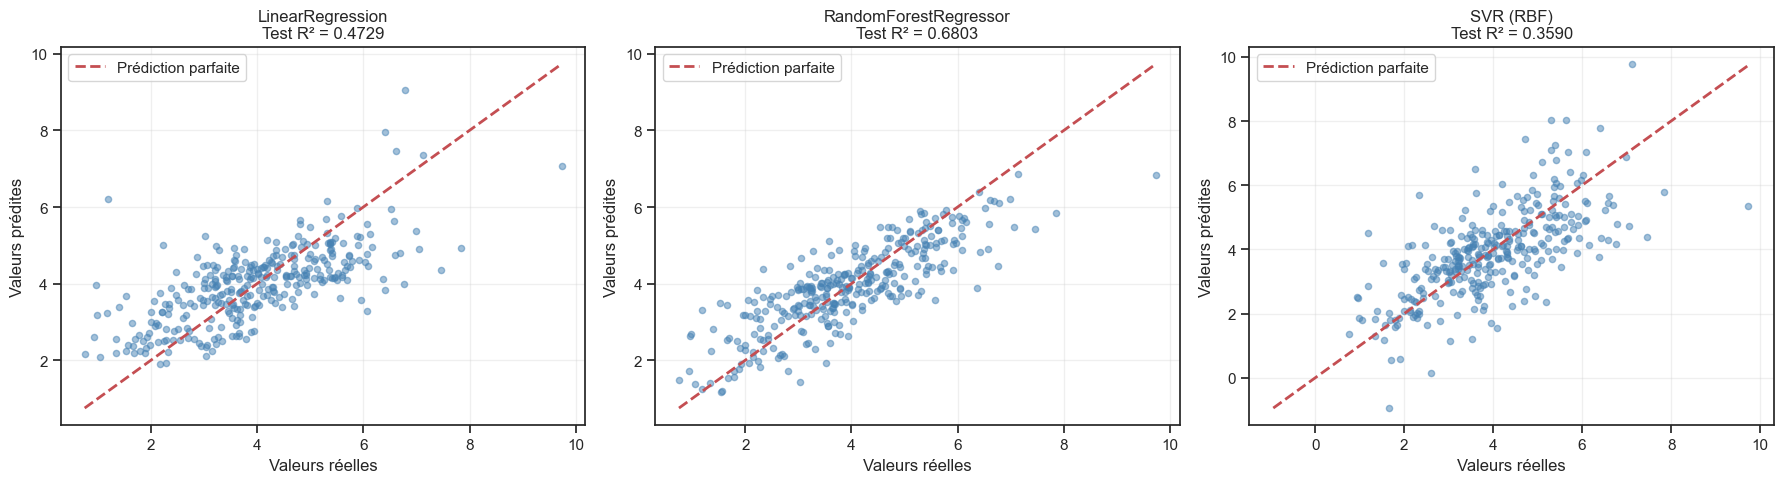


                            COMPARAISON DES MODÈLES                             

               Modèle Train R² Test R² Test MAE Test RMSE Surapprentissage
     LinearRegression   0.5733  0.4729   164.59   1002.58          +0.1004
RandomForestRegressor   0.9617  0.6803   118.20    902.71          +0.2814
            SVR (RBF)   0.8999  0.3590   228.63   1339.06          +0.5409

MEILLEUR MODÈLE: RandomForestRegressor (Test R² = 0.6803)



In [4019]:
# Lancer la fonction de comparaison des modèles pour la variable cible "TotalGHGEmissions"
# 4. SÉPARATION TRAIN / TEST
print("\n" + "="*60)
print("4. SÉPARATION TRAIN / TEST (80/20) pour TotalGHGEmissions")
print("="*60)

X_ghg_train, X_ghg_test, y_ghg_train, y_ghg_test = train_test_split(X, y_ghg, test_size=0.2, random_state=42)

print(f"Taille du jeu train: {X_ghg_train.shape[0]} ({100*X_ghg_train.shape[0]/X.shape[0]:.1f}%)")
print(f"Taille du jeu test: {X_ghg_test.shape[0]} ({100*X_ghg_test.shape[0]/X.shape[0]:.1f}%)")

# 5. COMPARAISON DES MODÈLES pour la variable cible "TotalGHGEmissions"
print("5. COMPARAISON DES MODÈLES pour la variable cible TotalGHGEmissions")
print("\n" + "="*60)
results_ghg_lr, results_ghg_rf, results_ghg_svr = train_and_compare_models(X_ghg_train, X_ghg_test, y_ghg_train, y_ghg_test)

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [4020]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE
from functools import reduce
import operator

# ===================== GRIDSEARCH: OPTIMISATION DU RANDOMFOREST =====================

print("\n" + "="*70)
print("OPTIMISATION: GridSearchCV sur RandomForestRegressor")
print("="*70)

# 1. DÉFINIR LA GRILLE D'HYPERPARAMÈTRES (10 combinaisons environ)
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 10],
    'max_features': ['sqrt', 'log2']
}

# `min_samples_leaf` [2, 4, 10] :** C'est votre arme principale contre le surapprentissage. En forçant chaque feuille à avoir au moins 4 ou 10 échantillons, vous empêchez l'arbre de créer des règles spécifiques pour un seul bâtiment "atypique".
# `max_depth` [10, 15, 20] :** Au lieu d'aller jusqu'à 40 (ce qui est très profond et favorise l'overfitting), on teste des profondeurs plus raisonnables qui obligent le modèle à généraliser.
# `max_features` :** En ne regardant qu'une partie des colonnes pour chaque division (la racine carrée du nombre total de colonnes), on décorrèle les arbres, ce qui rend la "forêt" beaucoup plus robuste.

print("\nGrille d'hyperparamètres à tester:")
print(f"  n_estimators: {param_grid['n_estimators']}")
print(f"  max_depth: {param_grid['max_depth']}")
print(f"  min_samples_split: {param_grid['min_samples_split']}")
print(f"  min_samples_leaf: {param_grid['min_samples_leaf']}")

# Calculer le nombre de combinaisons
n_combinations = reduce(operator.mul, [len(v) for v in param_grid.values()], 1)
print(f"  Total: {n_combinations} combinaisons à tester")

def train_and_optimize_rf(X_train, X_test, y_train, y_test, results_rf, target_name):
    # 2. INITIALISER GRIDSEARCH
    print("\nInitialisation de GridSearchCV...")
    grid_search = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
        param_grid=param_grid,
        cv=5,  # 5-fold cross-validation
        scoring='r2',
        n_jobs=-1,  # Parallélisation
        verbose=1
    )

    # 3. EXÉCUTER LA RECHERCHE
    print("\nEntraînement en cours... (cela peut prendre quelques secondes)")
    grid_search.fit(X_train, y_train)

    print("\nGridSearch terminée!")
    print("\nMEILLEURS HYPERPARAMÈTRES TROUVÉS:")
    for param, value in grid_search.best_params_.items():
        print(f"  {param}: {value}")

    print(f"\nMeilleur score CV (R²): {grid_search.best_score_:.4f}")

    # 4. ÉVALUER LE MEILLEUR MODÈLE
    print("\n" + "="*70)
    print("ÉVALUATION: Meilleur modèle vs Baseline")
    print("="*70)

    best_model = grid_search.best_estimator_

    # Prédictions
    y_train_pred_best = best_model.predict(X_train)
    y_test_pred_best = best_model.predict(X_test)

    # Inversion de la transformation pour les métriques d'erreur (MAE, RMSE)
    y_test_real = np.expm1(y_test)
    y_test_pred_real = np.expm1(y_test_pred_best)

    # Calcul des métriques
    # Le R2 peut rester sur l'échelle log (il évalue la qualité de l'ajustement)
    train_r2_best = r2_score(y_train, y_train_pred_best)
    test_r2_best = r2_score(y_test, y_test_pred_best)

    # MAE et RMSE calculés sur les valeurs réelles pour être interprétables
    test_mae_best = mean_absolute_error(y_test_real, y_test_pred_real)
    test_rmse_best = np.sqrt(mean_squared_error(y_test_real, y_test_pred_real))

    print("\nMODÈLE OPTIMISÉ (GridSearch):")
    print(f"  Train R²: {train_r2_best:.4f}")
    print(f"  Test R²:  {test_r2_best:.4f}")
    print(f"  Test MAE: {test_mae_best:.2f}")
    print(f"  Test RMSE: {test_rmse_best:.2f}")

    print("\nMODÈLE BASELINE (RandomForest initial):")
    print(f"  Train R²: {results_rf['train_r2']:.4f}")
    print(f"  Test R²:  {results_rf['test_r2']:.4f}")
    print(f"  Test MAE: {results_rf['test_mae']:.2f}")
    print(f"  Test RMSE: {results_rf['test_rmse']:.2f}")

    # Calcul de l'amélioration
    improvement_r2 = test_r2_best - results_rf['test_r2']
    improvement_mae = results_rf['test_mae'] - test_mae_best

    print("\nAMÉLIORATIONS:")
    print(f"  Δ Test R²: {improvement_r2:+.4f}")
    print(f"  Δ Test MAE: {improvement_mae:+.2f}")

    # ===================== FEATURE IMPORTANCE =====================

    print("\n\n" + "="*70)
    print("INTERPRÉTATION: Feature Importance")
    print("="*70)

    # 1. EXTRAIRE LES FEATURE IMPORTANCES
    feature_importance = best_model.feature_importances_
    feature_names = X.columns

    # Créer un DataFrame pour travailler facilement
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values(by='Importance', ascending=False)

    print("\nRanking des features par importance:")
    for idx, row in importance_df.iterrows():
        print(f"  {row['Feature']:30s}: {row['Importance']:.6f}")

    # 2. VISUALISER SOUS FORME D'HISTOGRAMME
    print("\nCréation de l'histogramme des feature importances...")

    fig, ax = plt.subplots(figsize=(12, 6))

    # Créer le bar plot
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_df)))
    ax.barh(range(len(importance_df)), importance_df['Importance'], color=colors)


    # Configuration du graphique
    ax.set_yticks(range(len(importance_df)))
    # En pourcentage de l'importance totale
    ax.set_yticklabels(importance_df['Feature'])
    ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
    ax.set_title(f'Feature Importance - {target_name} ', fontsize=14, fontweight='bold')
    ax.invert_yaxis()  # Afficher la plus importante en haut

    # Ajouter les valeurs sur les barres
    for i, (idx, row) in enumerate(importance_df.iterrows()):
        row100 = row['Importance'] * 100
        ax.text(row['Importance'] + 0.005, i, f"{row100:.2f}%", 
                va='center', fontsize=10)

    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 3. RÉSUMÉ: TOP 5 FEATURES
    print("\nTOP 5 FEATURES LES PLUS IMPACTANTES:")
    top_5 = importance_df.head(5)
    for idx, (_, row) in enumerate(top_5.iterrows(), 1):
        percentage = (row['Importance'] / feature_importance.sum()) * 100
        print(f"  {idx}. {row['Feature']:30s}: {row['Importance']:.6f} ({percentage:.2f}%)")

    print(f"\nNote: Ces {len(top_5)} features représentent {importance_df.head(5)['Importance'].sum():.2%} de l'importance totale")



OPTIMISATION: GridSearchCV sur RandomForestRegressor

Grille d'hyperparamètres à tester:
  n_estimators: [200, 300, 500]
  max_depth: [10, 15, 20, None]
  min_samples_split: [5, 10, 15]
  min_samples_leaf: [2, 4, 10]
  Total: 216 combinaisons à tester



OPTIMISATION: GridSearchCV sur RandomForestRegressor

Initialisation de GridSearchCV...

Entraînement en cours... (cela peut prendre quelques secondes)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

GridSearch terminée!

MEILLEURS HYPERPARAMÈTRES TROUVÉS:
  max_depth: 20
  max_features: log2
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 500

Meilleur score CV (R²): 0.7511

ÉVALUATION: Meilleur modèle vs Baseline

MODÈLE OPTIMISÉ (GridSearch):
  Train R²: 0.9115
  Test R²:  0.7186
  Test MAE: 3797007.13
  Test RMSE: 23792449.21

MODÈLE BASELINE (RandomForest initial):
  Train R²: 0.9674
  Test R²:  0.7403
  Test MAE: 3620472.76
  Test RMSE: 22870121.91

AMÉLIORATIONS:
  Δ Test R²: -0.0217
  Δ Test MAE: -176534.37


INTERPRÉTATION: Feature Importance

Ranking des features par importance:
  PropertyGFATotal              : 0.385049
  NumberofFloors                : 0.139531
  PrimaryPropertyType           : 0.097786
  GFAPerFloor                   : 0.0976

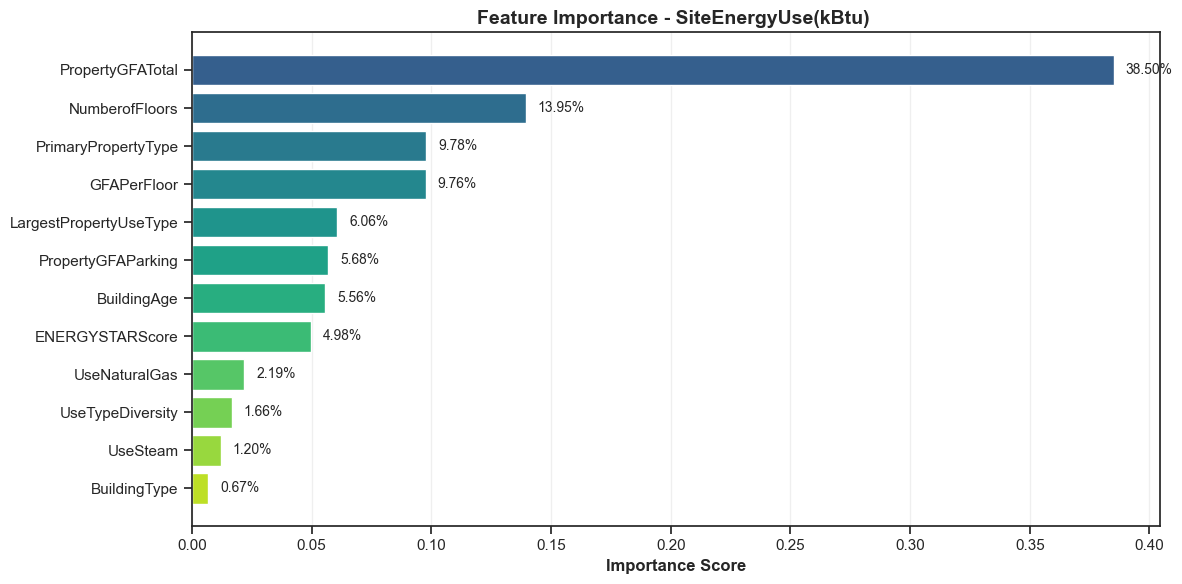


TOP 5 FEATURES LES PLUS IMPACTANTES:
  1. PropertyGFATotal              : 0.385049 (38.50%)
  2. NumberofFloors                : 0.139531 (13.95%)
  3. PrimaryPropertyType           : 0.097786 (9.78%)
  4. GFAPerFloor                   : 0.097612 (9.76%)
  5. LargestPropertyUseType        : 0.060611 (6.06%)

Note: Ces 5 features représentent 78.06% de l'importance totale


In [4021]:
# OPTIMISATION ET INTERPRETATION DU MODELE Pour la variable cible "SiteEnergyUse(kBtu)"
print("\n" + "="*70)
print("OPTIMISATION: GridSearchCV sur RandomForestRegressor")
print("="*70)
train_and_optimize_rf(X_energy_train, X_energy_test, y_energy_train, y_energy_test, results_rf=results_energy_rf, target_name="SiteEnergyUse(kBtu)")


OPTIMISATION: GridSearchCV sur RandomForestRegressor

Initialisation de GridSearchCV...

Entraînement en cours... (cela peut prendre quelques secondes)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

GridSearch terminée!

MEILLEURS HYPERPARAMÈTRES TROUVÉS:
  max_depth: 20
  max_features: log2
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 300

Meilleur score CV (R²): 0.7245

ÉVALUATION: Meilleur modèle vs Baseline

MODÈLE OPTIMISÉ (GridSearch):
  Train R²: 0.9009
  Test R²:  0.6746
  Test MAE: 120.93
  Test RMSE: 915.69

MODÈLE BASELINE (RandomForest initial):
  Train R²: 0.9617
  Test R²:  0.6803
  Test MAE: 118.20
  Test RMSE: 902.71

AMÉLIORATIONS:
  Δ Test R²: -0.0057
  Δ Test MAE: -2.73


INTERPRÉTATION: Feature Importance

Ranking des features par importance:
  PropertyGFATotal              : 0.281173
  UseNaturalGas                 : 0.174059
  NumberofFloors                : 0.102416
  GFAPerFloor                   : 0.092035
  PrimaryPropertyTyp

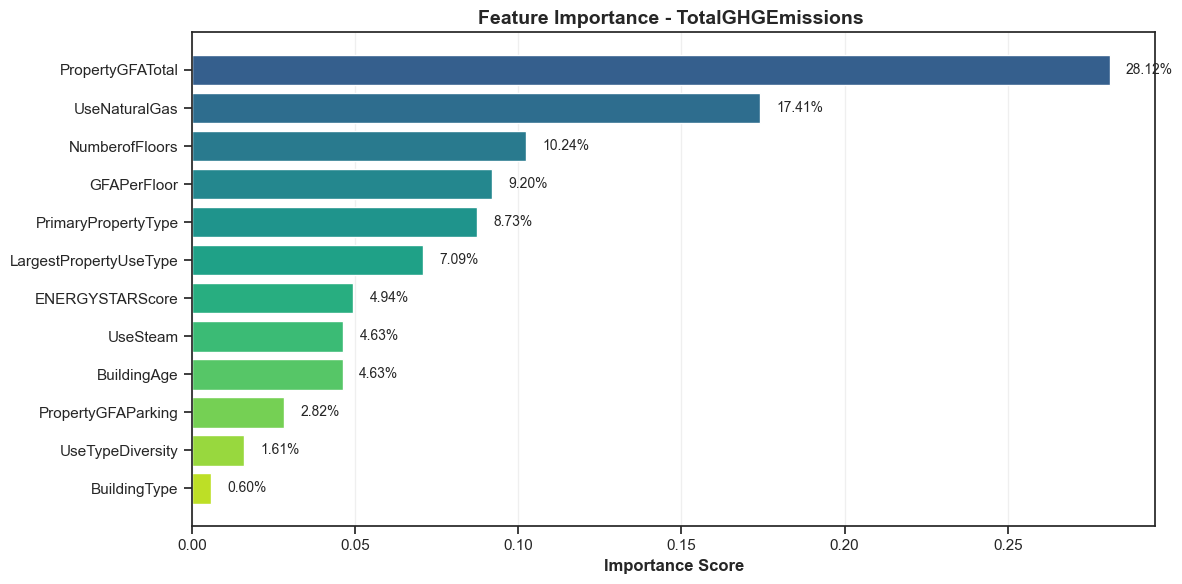


TOP 5 FEATURES LES PLUS IMPACTANTES:
  1. PropertyGFATotal              : 0.281173 (28.12%)
  2. UseNaturalGas                 : 0.174059 (17.41%)
  3. NumberofFloors                : 0.102416 (10.24%)
  4. GFAPerFloor                   : 0.092035 (9.20%)
  5. PrimaryPropertyType           : 0.087260 (8.73%)

Note: Ces 5 features représentent 73.69% de l'importance totale


In [4022]:
# OPTIMISATION ET INTERPRETATION DU MODELE Pour la variable cible "TotalGHGEmissions"
print("\n" + "="*70)
print("OPTIMISATION: GridSearchCV sur RandomForestRegressor")
print("="*70)
train_and_optimize_rf(X_ghg_train, X_ghg_test, y_ghg_train, y_ghg_test, results_rf=results_ghg_rf, target_name="TotalGHGEmissions")